# AI for Communication and Marketing  
## Lab Exam – Part 3

**Academic Year:** 2025/2026  
**Course:** B.Sc. in Artificial Intelligence  
**Student:** Marta Paniconi · 535358

---

## Business Scenario

In this lab exam, we act as Lead Data Scientist for **Olist**, one of the largest Brazilian e-commerce marketplaces. The Marketing Department is planning its budget allocation and loyalty campaigns for the upcoming quarter and needs a **forward-looking estimate of customer value** to support data-driven decisions.

The objective of this project is to build a predictive framework for **Customer Lifetime Value (CLTV)** by combining two complementary approaches:

1. A **probabilistic BTYD approach** based on the BG/NBD and Gamma-Gamma models.  
   This approach is particularly suitable for non-contractual settings, where customers can stop purchasing without explicitly cancelling a relationship with the company.

2. A **Machine Learning regression approach**, based on customer-level features engineered from the calibration period.  
   This approach aims to predict the total revenue generated by each customer during the holdout period.

Both approaches will be evaluated on a holdout period and compared using standard regression metrics: **MAE, MSE and RMSE**.

The final results will be translated into actionable marketing recommendations for two decision-making levels:

- **Macro view – Financial Planning:** estimating the total future value of the current customer base to support budget allocation.
- **Micro view – Operational Marketing:** identifying customers to prioritize for win-back or retention campaigns based on predicted CLTV and probability of being alive.

---

## Dataset

This project uses the **Brazilian E-Commerce Public Dataset by Olist**, a relational dataset containing more than 100,000 orders placed between 2016 and 2018 across multiple Brazilian marketplaces.

Among the available tables, the analysis focuses on the four datasets that are most relevant for CLTV modeling:

- `olist_orders_dataset` — order status and purchase timestamps
- `olist_order_items_dataset` — order-level product prices and freight values
- `olist_order_payments_dataset` — payment information and payment values
- `olist_customers_dataset` — customer identifiers and customer location information

These tables are aggregated to create a clean **transaction-level dataset** suitable for CLTV analysis. The final transaction log uses:

- `customer_unique_id` as the customer identifier
- `order_purchase_timestamp` as the transaction date
- `Revenue` as the monetary value of each transaction

This structure is required both by the `lifetimes` library for probabilistic CLTV modeling and by the Machine Learning pipeline used to predict holdout-period revenue.

# TASK A — Data Audit & Cleaning

This section performs a structured audit and cleaning of the Olist relational dataset before building the transaction log required for CLTV modeling.

The goal is to validate data types, missing values, duplicated records, business rules, invalid transactions and monetary outliers before aggregating the relational tables.

The output of Task A will be a clean **transaction-level table**, where each row represents one completed order and contains the three essential elements required for CLTV analysis:

- a stable customer identifier;
- a transaction timestamp;
- a monetary value.

## A.1 Load libraries and dataset

We begin by importing the basic libraries needed for data manipulation, visualization and inspection.

At this stage, we only load the four Olist tables required to build the CLTV transaction log:

- `orders`, which contains order status and timestamps;
- `order_items`, which contains product prices and freight values;
- `order_payments`, which contains the amount paid by the customer;
- `customers`, which contains the stable customer identifier.

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot and display defaults
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Path to the Olist CSV files
DATA_DIR = "./data/"

# Load the four tables relevant to CLTV modeling
orders    = pd.read_csv(DATA_DIR + "olist_orders_dataset.csv")
items     = pd.read_csv(DATA_DIR + "olist_order_items_dataset.csv")
payments  = pd.read_csv(DATA_DIR + "olist_order_payments_dataset.csv")
customers = pd.read_csv(DATA_DIR + "olist_customers_dataset.csv")

print(f"orders:    {orders.shape}")
print(f"items:     {items.shape}")
print(f"payments:  {payments.shape}")
print(f"customers: {customers.shape}")

orders.head(3)

orders:    (99441, 8)
items:     (112650, 7)
payments:  (103886, 5)
customers: (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


### A.2 Data type audit and datetime conversion

The Olist dataset stores timestamp variables as object/string columns by default.  
Before computing time-dependent variables such as recency, customer tenure, calibration-period activity and holdout-period revenue, these columns must be converted into proper datetime format.

In this step, we only convert data types and inspect the available time range. We do not remove observations yet: missing dates, invalid statuses and business anomalies will be evaluated in the following audit steps.

In [3]:
# 1. Inspect original data types before conversion
print("Orders dtypes before conversion:")
print(orders.dtypes)

print("\nItems dtypes before conversion:")
print(items.dtypes)

print("\nPayments dtypes before conversion:")
print(payments.dtypes)

# 2. Convert all timestamp columns in orders to datetime
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# 3. Convert the shipping limit date in items to datetime
items["shipping_limit_date"] = pd.to_datetime(
    items["shipping_limit_date"],
    errors="coerce"
)

# 4. Convert monetary columns to numeric format
# They are usually already numeric in the Olist dataset, but this makes the pipeline explicit and robust
for col in ["price", "freight_value"]:
    items[col] = pd.to_numeric(items[col], errors="coerce")

payments["payment_value"] = pd.to_numeric(
    payments["payment_value"],
    errors="coerce"
)

# 5. Verify data types after conversion
print("Orders dtypes after conversion:")
print(orders.dtypes)

print("\nItems dtypes after conversion:")
print(items.dtypes)

print("\nPayments dtypes after conversion:")
print(payments.dtypes)

# 6. Inspect the purchase timestamp range
purchase_min = orders["order_purchase_timestamp"].min()
purchase_max = orders["order_purchase_timestamp"].max()
purchase_span = (purchase_max - purchase_min).days

print("\nOrder purchase timestamp range:")
print(f"Min date: {purchase_min}")
print(f"Max date: {purchase_max}")
print(f"Span: {purchase_span} days")

Orders dtypes before conversion:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Items dtypes before conversion:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Payments dtypes before conversion:
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object
Orders dtypes after conversion:
order_id                                    str
customer_id                                 str
order_status                                str
order_p

- All relevant timestamp columns are now stored as `datetime64`, allowing reliable time-based calculations in the next tasks.

- The numerical fields needed to define transaction value, such as `price`, `freight_value` and `payment_value`, are stored as numeric variables. This is important because these fields will later be aggregated at order level to construct the monetary component of the CLTV transaction log.

- The purchase timestamp range spans approximately 695 days, providing sufficient historical coverage to define a calibration period for model training and a 90-day holdout period for evaluating future revenue predictions.


### A.3 Missing values, duplicates and key uniqueness

In this step, we audit three data-quality dimensions that directly affect the construction of the CLTV transaction log.

1. First, we inspect **missing values**, especially in the `orders` table, where delivery timestamps may be empty for cancelled, unavailable or undelivered orders. These missing values should not be treated automatically as data errors, because in many cases they reflect the real order lifecycle.

2. Second, we check **duplicate rows**. Full-row duplicates may indicate import problems, while repeated `order_id` values in `items` and `payments` are expected because one order can contain multiple products and multiple payment installments.

3. Third, we verify **key uniqueness** to understand how the four relational tables should be joined. This is especially important for customer-level modeling: in Olist, `customer_id` is linked to a single order, while `customer_unique_id` identifies the same customer across multiple orders. For CLTV and RFM analysis, the correct customer identifier is therefore `customer_unique_id`.

In [4]:
# Tables used in the audit
audit_tables = {
    "orders": orders,
    "items": items,
    "payments": payments,
    "customers": customers
}

# 1. Missing values report in long format
missing_report = []

for table_name, df in audit_tables.items():
    missing_count = df.isna().sum()
    missing_pct = missing_count / len(df) * 100
    
    for column in df.columns:
        if missing_count[column] > 0:
            missing_report.append({
                "table": table_name,
                "column": column,
                "missing_count": missing_count[column],
                "missing_pct": missing_pct[column]
            })

missing_report = pd.DataFrame(missing_report)
display(missing_report.sort_values(["table", "missing_pct"], ascending=[True, False]))


# 2. Full-row duplicates by table
duplicate_report = pd.DataFrame({
    "table": list(audit_tables.keys()),
    "rows": [len(df) for df in audit_tables.values()],
    "duplicate_rows": [df.duplicated().sum() for df in audit_tables.values()]
})

display(duplicate_report)


# 3. Key structure and uniqueness
key_report = pd.DataFrame({
    "metric": [
        "orders rows",
        "orders unique order_id",
        "orders.order_id is unique",
        "orders unique customer_id",
        "customers rows",
        "customers unique customer_id",
        "customers.customer_id is unique",
        "customers unique customer_unique_id",
        "items rows",
        "items unique order_id",
        "payments rows",
        "payments unique order_id"
    ],
    "value": [
        len(orders),
        orders["order_id"].nunique(),
        orders["order_id"].is_unique,
        orders["customer_id"].nunique(),
        len(customers),
        customers["customer_id"].nunique(),
        customers["customer_id"].is_unique,
        customers["customer_unique_id"].nunique(),
        len(items),
        items["order_id"].nunique(),
        len(payments),
        payments["order_id"].nunique()
    ]
})

display(key_report)


# 4. Repeat-customer analysis based on customer_unique_id
orders_per_customer_schema = (
    customers
    .groupby("customer_unique_id")["customer_id"]
    .nunique()
)

repeat_customer_report = pd.DataFrame({
    "metric": [
        "unique customers",
        "order-level customer_id",
        "customers with more than one order",
        "repeat-customer rate (%)"
    ],
    "value": [
        customers["customer_unique_id"].nunique(),
        customers["customer_id"].nunique(),
        (orders_per_customer_schema > 1).sum(),
        round((orders_per_customer_schema > 1).mean() * 100, 2)
    ]
})

display(repeat_customer_report)

,table,column,missing_count,missing_pct
2,orders,order_delivered_customer_date,2965,2.98
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16


,table,rows,duplicate_rows
0,orders,99441,0
1,items,112650,0
2,payments,103886,0
3,customers,99441,0


,metric,value
0,orders rows,99441
1,orders unique order_id,99441
2,orders.order_id is unique,True
3,orders unique customer_id,99441
4,customers rows,99441
5,customers unique customer_id,99441
6,customers.customer_id is unique,True
7,customers unique customer_unique_id,96096
8,items rows,112650
9,items unique order_id,98666


,metric,value
0,unique customers,"96,096.00"
1,order-level customer_id,"99,441.00"
2,customers with more than one order,"2,997.00"
3,repeat-customer rate (%),3.12


- The missing-value audit shows that missing values are concentrated in the `orders` table, especially in delivery-related timestamps such as `order_approved_at`, `order_delivered_carrier_date` and `order_delivered_customer_date`. These missing values should not be interpreted immediately as data errors, because they are often linked to the order lifecycle: cancelled, unavailable or not-yet-delivered orders naturally do not have complete delivery timestamps.

- The duplicate audit shows that there are no full-row duplicates in the four tables. This means that there is no evidence of repeated imported records that should be removed at this stage.

- The key audit confirms the relational structure of the Olist dataset. The `orders` table is order-level, while `items` and `payments` contain repeated `order_id` values because one order may include multiple products or multiple payment installments. Therefore, `items` and `payments` must be aggregated at `order_id` level before being merged with the order table.

- Most importantly, the audit confirms that `customer_id` and `customer_unique_id` have different meanings. `customer_id` is an order-level identifier, while `customer_unique_id` is the stable customer identifier across orders. Since CLTV requires tracking the same customer over time, all RFM and CLTV features will be built using `customer_unique_id`.

### A.4 Order status filter and anomaly audit

CLTV models require each row in the transaction log to represent an actual completed purchase. Before building the final transaction table, we therefore verify two business-critical conditions.

First, we inspect the **order status**. In the Olist dataset, `order_status` describes the lifecycle of each order through categories such as `delivered`, `shipped`, `canceled`, `invoiced`, `processing`, `unavailable`, `created` and `approved`. For CLTV purposes, only `delivered` orders can be safely interpreted as realized transactions. The other statuses either refer to orders that did not materialize, such as cancelled or unavailable orders, or to orders that were still in progress at the time of data collection. Including them would artificially inflate purchase frequency and could bias the monetary value used in the models.

Second, we perform a **price and payment sanity check**. We verify that item prices and payment values are valid, and we inspect the distribution of order-level revenue. This step is necessary because CLTV models, especially the Gamma-Gamma monetary model and the Machine Learning regression model, can be sensitive to extreme monetary values. For this reason, we identify potential outliers and later decide whether to cap extreme order values rather than remove customers from the analysis.

In [5]:
# 1. Order status distribution
status_audit = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)

status_audit["percentage"] = (
    status_audit["orders"] / len(orders) * 100
).round(2)

display(status_audit)


# 2. Missing delivery timestamp by order status
missing_delivery_audit = (
    orders
    .assign(
        missing_customer_delivery=orders["order_delivered_customer_date"].isna()
    )
    .groupby("order_status", as_index=False)
    .agg(
        orders=("order_id", "count"),
        missing_delivery_rows=("missing_customer_delivery", "sum")
    )
)

missing_delivery_audit["missing_delivery_pct"] = (
    missing_delivery_audit["missing_delivery_rows"]
    / missing_delivery_audit["orders"] * 100
).round(2)

display(missing_delivery_audit)


# 3. Monetary sanity checks on raw tables
monetary_audit = pd.DataFrame({
    "table": ["items", "items", "payments"],
    "variable": ["price", "freight_value", "payment_value"],
    "missing_rows": [
        items["price"].isna().sum(),
        items["freight_value"].isna().sum(),
        payments["payment_value"].isna().sum()
    ],
    "non_positive_rows": [
        (items["price"] <= 0).sum(),
        (items["freight_value"] < 0).sum(),
        (payments["payment_value"] <= 0).sum()
    ],
    "min_value": [
        items["price"].min(),
        items["freight_value"].min(),
        payments["payment_value"].min()
    ],
    "max_value": [
        items["price"].max(),
        items["freight_value"].max(),
        payments["payment_value"].max()
    ]
})

display(monetary_audit)


# 4. Temporary order-level aggregation for revenue anomaly audit
items_order_audit = (
    items
    .groupby("order_id", as_index=False)
    .agg(
        item_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        n_items=("order_item_id", "count")
    )
)

payments_order_audit = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        n_payments=("payment_sequential", "count")
    )
)

order_audit = (
    orders[orders["order_status"] == "delivered"]
    .merge(items_order_audit, on="order_id", how="left")
    .merge(payments_order_audit, on="order_id", how="left")
)

order_audit["item_plus_freight"] = (
    order_audit["item_revenue"] + order_audit["freight_value"]
)

order_audit["payment_item_gap"] = (
    order_audit["payment_value"] - order_audit["item_plus_freight"]
)


# 5. Delivered-order revenue distribution
revenue_distribution = (
    order_audit["payment_value"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame()
    .T
)

display(revenue_distribution)


# 6. Outlier thresholds for order revenue
q1 = order_audit["payment_value"].quantile(0.25)
q3 = order_audit["payment_value"].quantile(0.75)
iqr = q3 - q1

iqr_threshold = q3 + 1.5 * iqr
p99_threshold = order_audit["payment_value"].quantile(0.99)

outlier_audit = pd.DataFrame({
    "rule": ["IQR threshold", "99th percentile cap"],
    "threshold": [iqr_threshold, p99_threshold],
    "orders_above_threshold": [
        (order_audit["payment_value"] > iqr_threshold).sum(),
        (order_audit["payment_value"] > p99_threshold).sum()
    ],
    "percentage_of_delivered_orders": [
        (order_audit["payment_value"] > iqr_threshold).mean() * 100,
        (order_audit["payment_value"] > p99_threshold).mean() * 100
    ]
})

display(outlier_audit)

,order_status,orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


,order_status,orders,missing_delivery_rows,missing_delivery_pct
0,approved,2,2,100.00
1,canceled,625,619,99.04
2,created,5,5,100.00
3,delivered,96478,8,0.01
4,invoiced,314,314,100.00
5,processing,301,301,100.00
6,shipped,1107,1107,100.00
7,unavailable,609,609,100.00


,table,variable,missing_rows,non_positive_rows,min_value,max_value
0,items,price,0,0,0.85,"6,735.00"
1,items,freight_value,0,0,0.00,409.68
2,payments,payment_value,0,9,0.00,"13,664.08"


,count,mean,std,min,50%,75%,90%,95%,99%,max
payment_value,"96,477.00",159.86,218.81,9.59,105.28,176.33,305.97,446.31,"1,052.39","13,664.08"


,rule,threshold,orders_above_threshold,percentage_of_delivered_orders
0,IQR threshold,348.00,7576,7.85
1,99th percentile cap,"1,052.39",965,1.00


1. The order-status audit confirms that the dataset is dominated by completed transactions: `delivered` orders represent about 97% of all orders. For CLTV modeling, this is the only status that can be safely interpreted as realized customer value. The remaining statuses refer to cancelled, unavailable or still in-progress orders and will therefore be excluded from the transaction log.

2. The missing delivery timestamp analysis supports this decision. Missing delivery dates are highly concentrated among non-delivered statuses such as `canceled`, `unavailable`, `processing`, `shipped`, `created` and `approved`. This indicates that missing timestamps mostly reflect the natural order lifecycle rather than random data-quality problems. The few delivered orders with missing delivery timestamps are not critical for this analysis, because CLTV will be based on the purchase timestamp, not on the delivery date.

3. The monetary audit shows that item prices and freight values do not present problematic negative values. Freight can be equal to zero, which is acceptable because some orders may include free shipping. Payment values are generally valid, although a very small number of orders have non-positive payment values. These transactions do not represent positive customer revenue and will be removed in the cleaning pipeline.

4. Finally, the delivered-order revenue distribution is strongly right-skewed. The median order value is much lower than the maximum value, meaning that a small number of very large orders could disproportionately influence the monetary component of CLTV. The IQR rule identifies a relatively large share of orders as outliers, which would be too aggressive for e-commerce data where high-value purchases may be legitimate. For this reason, the modeling revenue variable will be capped at the 99th percentile. This preserves almost the entire customer base while reducing the impact of extreme transactions on the Gamma-Gamma and Machine Learning models.

### A.5 Cleaning pipeline and transaction-log construction

After auditing the relational tables, we build the clean transaction log that will be used in both the BTYD model and the Machine Learning regression model.

The pipeline applies five business rules.

1. First, we keep only completed transactions by filtering `order_status == "delivered"`. Cancelled, unavailable and in-progress orders are excluded because they do not represent realized customer value.

2. Second, we resolve the customer identity by joining the `customers` table and replacing the order-level `customer_id` with the stable person-level `customer_unique_id`. This step is essential because CLTV requires tracking the same customer across multiple orders.

3. Third, we aggregate `items` and `payments` at order level before merging. This avoids row multiplication, since a single order may contain multiple products and multiple payment installments.

4. Fourth, we define `Revenue_raw` using `payment_value`, because it represents the amount actually paid by the customer. We keep item revenue and freight value as audit variables.

5. Finally, we remove transactions with missing critical information or non-positive revenue, and we create a cleaned `Revenue` variable by capping extreme values at the 99th percentile.

In [6]:
# 1. Keep only delivered orders
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# 2. Aggregate item-level data at order level
items_order = (
    items
    .groupby("order_id", as_index=False)
    .agg(
        item_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        n_items=("order_item_id", "count")
    )
)

# 3. Aggregate payment-level data at order level
payments_order = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        n_payments=("payment_sequential", "count")
    )
)

# 4. Merge delivered orders with customers, items and payments
transactions = (
    orders_delivered
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .merge(items_order, on="order_id", how="left")
    .merge(payments_order, on="order_id", how="left")
)

# 5. Define revenue variables and audit gap
transactions["Revenue_raw"] = transactions["payment_value"]

transactions["item_plus_freight"] = (
    transactions["item_revenue"] + transactions["freight_value"]
)

transactions["payment_item_gap"] = (
    transactions["payment_value"] - transactions["item_plus_freight"]
)

# 6. Keep only variables needed for CLTV modeling and audit
transactions = transactions[[
    "order_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "item_revenue",
    "freight_value",
    "item_plus_freight",
    "payment_value",
    "payment_item_gap",
    "Revenue_raw",
    "n_items",
    "n_payments"
]].copy()

n_merged = len(transactions)

# 7. Drop rows with missing critical fields
critical_cols = [
    "customer_unique_id",
    "order_purchase_timestamp",
    "item_revenue",
    "payment_value",
    "Revenue_raw",
    "n_items",
    "n_payments"
]

transactions_clean = transactions.dropna(subset=critical_cols).copy()
n_after_missing = len(transactions_clean)

# 8. Remove transactions with non-positive revenue
transactions_clean = transactions_clean[
    transactions_clean["Revenue_raw"] > 0
].copy()

n_after_positive = len(transactions_clean)

# 9. Cap extreme revenue values at the 99th percentile
revenue_cap = transactions_clean["Revenue_raw"].quantile(0.99)

transactions_clean["Revenue"] = (
    transactions_clean["Revenue_raw"]
    .clip(upper=revenue_cap)
)

transactions_clean["revenue_was_capped"] = (
    transactions_clean["Revenue_raw"] > revenue_cap
)

# 10. Convert count variables to integer
transactions_clean["n_items"] = transactions_clean["n_items"].astype(int)
transactions_clean["n_payments"] = transactions_clean["n_payments"].astype(int)

# 11. Sort final transaction log
transactions_clean = (
    transactions_clean
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .reset_index(drop=True)
)

# 12. Cleaning summary
cleaning_summary = pd.DataFrame({
    "step": [
        "Original orders",
        "Delivered orders",
        "After relational merge",
        "After dropping missing critical fields",
        "After removing non-positive revenue",
        "Final clean transaction log"
    ],
    "rows": [
        len(orders),
        len(orders_delivered),
        n_merged,
        n_after_missing,
        n_after_positive,
        len(transactions_clean)
    ]
})

display(cleaning_summary)

print(f"Revenue cap at 99th percentile: {revenue_cap:,.2f}")
print(f"Orders affected by clipping: {transactions_clean['revenue_was_capped'].sum():,}")

display(transactions_clean.head())

,step,rows
0,Original orders,99441
1,Delivered orders,96478
2,After relational merge,96478
3,After dropping missing critical fields,96477
4,After removing non-positive revenue,96477
5,Final clean transaction log,96477


Revenue cap at 99th percentile: 1,052.39
Orders affected by clipping: 965


,order_id,customer_unique_id,order_purchase_timestamp,item_revenue,freight_value,item_plus_freight,payment_value,payment_item_gap,Revenue_raw,n_items,n_payments,Revenue,revenue_was_capped
0,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,129.90,12.00,141.90,141.90,0.00,141.90,1,1,141.90,False
1,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,18.90,8.29,27.19,27.19,0.00,27.19,1,1,27.19,False
2,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,69.00,17.22,86.22,86.22,0.00,86.22,1,1,86.22,False
3,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,25.99,17.63,43.62,43.62,0.00,43.62,1,1,43.62,False
4,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,180.00,16.89,196.89,196.89,0.00,196.89,1,1,196.89,False


The cleaning pipeline produces a clean order-level transaction log with 96,477 completed purchases.

Starting from 99,441 original orders, the main reduction comes from the business-rule filter on `order_status == "delivered"`, which removes cancelled, unavailable and in-progress orders. This is consistent with the CLTV objective, because only completed purchases should contribute to realized customer value.

After the relational merge, the number of rows remains equal to the number of delivered orders. This confirms that aggregating `items` and `payments` at order level before the merge successfully avoided row multiplication. Only one transaction is removed because of missing critical information, and no additional rows are removed for non-positive revenue.

The final dataset uses `customer_unique_id` as the stable customer identifier, `order_purchase_timestamp` as the transaction date, and `Revenue` as the cleaned monetary value. The original payment amount is preserved in `Revenue_raw`, while `Revenue` is capped at the 99th percentile. This affects 965 orders, approximately 1% of the final transaction log, and reduces the influence of extreme order values without removing high-value customers from the analysis.

The resulting `transactions_clean` table is now suitable for the next step: EDA and RFM feature engineering.

### A.6 Final quality check

Before moving to EDA and RFM feature engineering, we verify that the cleaned transaction log satisfies the structural requirements for CLTV modeling.

The final table must contain:

- a stable customer identifier;
- a valid transaction timestamp;
- a strictly positive monetary value;
- one row per completed order;
- a sufficient time span to define calibration and holdout periods.

In [7]:
# 1. Final structural checks
final_quality_checks = pd.DataFrame({
    "check": [
        "missing customer_unique_id",
        "missing order_purchase_timestamp",
        "missing Revenue",
        "Revenue <= 0",
        "duplicated order_id",
        "final transactions",
        "unique customers",
        "average orders per customer"
    ],
    "value": [
        transactions_clean["customer_unique_id"].isna().sum(),
        transactions_clean["order_purchase_timestamp"].isna().sum(),
        transactions_clean["Revenue"].isna().sum(),
        (transactions_clean["Revenue"] <= 0).sum(),
        transactions_clean["order_id"].duplicated().sum(),
        len(transactions_clean),
        transactions_clean["customer_unique_id"].nunique(),
        len(transactions_clean) / transactions_clean["customer_unique_id"].nunique()
    ]
})

display(final_quality_checks)


# 2. Date range of the clean transaction log
date_range_summary = pd.DataFrame({
    "metric": [
        "start date",
        "end date",
        "time span in days"
    ],
    "value": [
        transactions_clean["order_purchase_timestamp"].min(),
        transactions_clean["order_purchase_timestamp"].max(),
        (
            transactions_clean["order_purchase_timestamp"].max()
            - transactions_clean["order_purchase_timestamp"].min()
        ).days
    ]
})

display(date_range_summary)


# 3. Orders per customer distribution
orders_per_customer = (
    transactions_clean
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

orders_distribution = (
    orders_per_customer
    .value_counts()
    .sort_index()
    .reset_index()
)

orders_distribution.columns = [
    "orders_per_customer",
    "number_of_customers"
]

display(orders_distribution.head(10))


# 4. Repeat-customer summary
repeat_customers = (orders_per_customer > 1).sum()
repeat_rate = repeat_customers / len(orders_per_customer) * 100

repeat_customer_summary = pd.DataFrame({
    "metric": [
        "customers with one order",
        "repeat customers",
        "repeat-customer rate (%)"
    ],
    "value": [
        (orders_per_customer == 1).sum(),
        repeat_customers,
        repeat_rate
    ]
})

display(repeat_customer_summary)


# 5. Save clean transaction log for the next tasks
transactions_clean.to_csv("olist_transactions_clean.csv", index=False)

,check,value
0,missing customer_unique_id,0.00
1,missing order_purchase_timestamp,0.00
2,missing Revenue,0.00
3,Revenue <= 0,0.00
4,duplicated order_id,0.00
5,final transactions,"96,477.00"
6,unique customers,"93,357.00"
7,average orders per customer,1.03


,metric,value
0,start date,2016-10-03 09:44:50
1,end date,2018-08-29 15:00:37
2,time span in days,695


,orders_per_customer,number_of_customers
0,1,90556
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


,metric,value
0,customers with one order,"90,556.00"
1,repeat customers,"2,801.00"
2,repeat-customer rate (%),3.00


The final quality check confirms that the cleaned transaction log satisfies the structural requirements for CLTV modeling.

- The table contains no missing values in the key columns required by the next tasks: `customer_unique_id`, `order_purchase_timestamp` and `Revenue`. Revenue is strictly positive, and there are no duplicated `order_id` values. This confirms that each row represents one completed transaction.

- The final transaction log contains 96,477 completed orders and 93,357 unique customers, with an average of approximately 1.03 orders per customer. The orders-per-customer distribution shows that most customers purchased only once, while 2,801 customers made more than one purchase, corresponding to a repeat-customer rate of about 3%.

- This is an important insight for both business interpretation and model design. From a marketing perspective, Olist has a broad customer base but limited repeat-purchase behavior. From a modeling perspective, this means that the Gamma-Gamma model will be fitted only on the subset of customers with repeat purchases, while the Machine Learning model will likely face a strong zero-revenue effect when predicting holdout-period revenue.

- Finally, the clean transaction log covers 695 days, from October 2016 to August 2018. This time span is sufficient to define a calibration period for model training and a 90-day holdout period for evaluation.

### Task A summary

Task A transformed the original relational Olist dataset into a clean order-level transaction log suitable for CLTV analysis.

The main cleaning decisions were:

- only `delivered` orders were retained, because CLTV must be estimated on realized purchases;
- `customer_unique_id` was selected as the stable customer identifier, allowing repeat purchases by the same person to be linked over time;
- item and payment data were aggregated at `order_id` level before merging, avoiding artificial row multiplication;
- `Revenue_raw` was preserved as the original payment amount;
- `Revenue` was created as the modeling monetary variable, capped at the 99th percentile to reduce the impact of extreme order values.

The resulting `transactions_clean` table is ready for Task B, where it will be transformed into customer-level RFM features: Recency, Frequency, Monetary Value and T.

---

## TASK B — Exploratory Data Analysis & RFM Feature Engineering

Task B moves from the cleaned transaction log to customer-level behavioral features.

The objective is twofold.
1. First, we explore purchase frequency, recency and customer spend to understand the retention profile of Olist customers.
2. Second, we transform the transaction-level dataset into an RFM table containing the variables required for CLTV modeling: Recency, Frequency, Monetary Value and T.

This step is important because the modeling task depends directly on how customer behavior is summarized over time.

### B.1 Transaction-level overview

We start by inspecting the cleaned transaction log produced in Task A.

At this stage, the data is still at order level: each row represents one completed purchase. The goal is to understand the overall scale of the dataset, the time coverage, the monthly purchase trend and the distribution of order revenue before moving to customer-level RFM features.

,metric,value
0,transactions,96477
1,unique customers,93357
2,first purchase date,2016-10-03 09:44:50
3,last purchase date,2018-08-29 15:00:37
4,total cleaned revenue,"14,834,208.82"
5,average order revenue,153.76
6,median order revenue,105.28


,month,orders,revenue,customers
0,2016-10-01,265,"46,195.55",262
1,2016-12-01,1,19.62,1
2,2017-01-01,750,"121,207.16",718
3,2017-02-01,1653,"252,335.50",1630
4,2017-03-01,2546,"391,839.33",2508


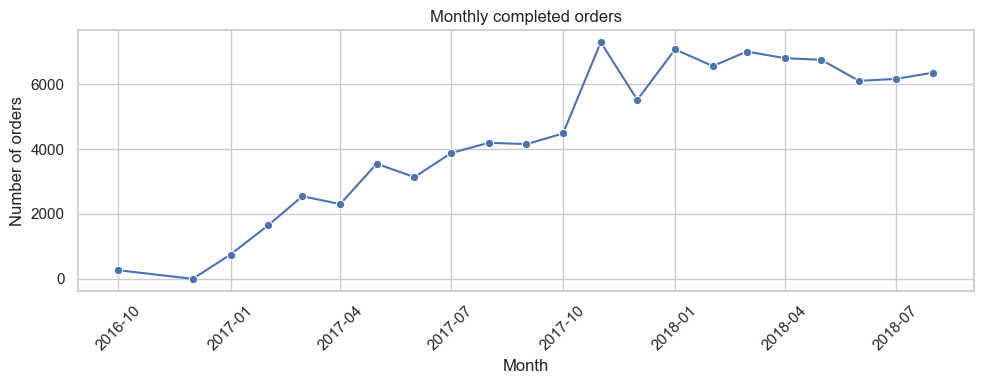

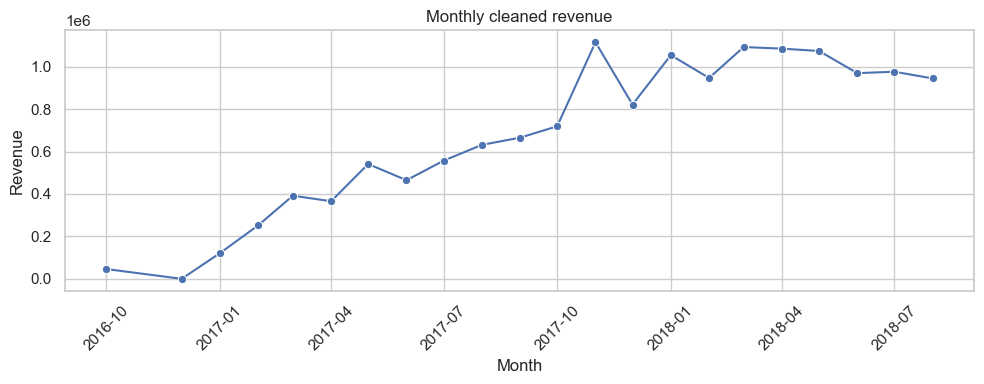

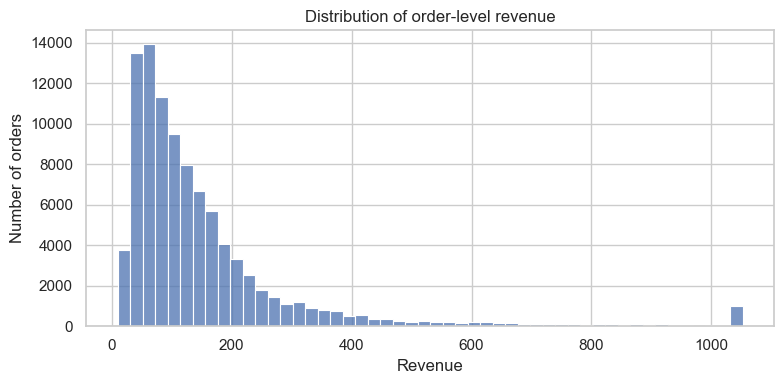

,count,mean,std,min,50%,75%,90%,95%,99%,max
Revenue,"96,477.00",153.76,163.82,9.59,105.28,176.33,305.97,446.31,"1,052.37","1,052.39"


In [8]:
# Make sure the transaction timestamp is in datetime format
transactions_clean["order_purchase_timestamp"] = pd.to_datetime(
    transactions_clean["order_purchase_timestamp"]
)

# Basic transaction-level KPIs
b1_overview = pd.DataFrame({
    "metric": [
        "transactions",
        "unique customers",
        "first purchase date",
        "last purchase date",
        "total cleaned revenue",
        "average order revenue",
        "median order revenue"
    ],
    "value": [
        len(transactions_clean),
        transactions_clean["customer_unique_id"].nunique(),
        transactions_clean["order_purchase_timestamp"].min(),
        transactions_clean["order_purchase_timestamp"].max(),
        transactions_clean["Revenue"].sum(),
        transactions_clean["Revenue"].mean(),
        transactions_clean["Revenue"].median()
    ]
})

display(b1_overview)


# Monthly transaction and revenue trend
monthly_trend = (
    transactions_clean
    .assign(month=transactions_clean["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("Revenue", "sum"),
        customers=("customer_unique_id", "nunique")
    )
)

display(monthly_trend.head())


# Plot monthly number of orders
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_trend, x="month", y="orders", marker="o")
plt.title("Monthly completed orders")
plt.xlabel("Month")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plot monthly cleaned revenue
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_trend, x="month", y="revenue", marker="o")
plt.title("Monthly cleaned revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Distribution of order-level revenue
plt.figure(figsize=(8, 4))
sns.histplot(transactions_clean["Revenue"], bins=50)
plt.title("Distribution of order-level revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()


# Revenue distribution summary
revenue_summary = (
    transactions_clean["Revenue"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame()
    .T
)

display(revenue_summary)


- The transaction-level overview confirms that the cleaned dataset contains **96,477** completed purchases made by **93,357** unique customers. The observation window extends from October 2016 to August 2018, providing enough historical depth to define a calibration period and a future holdout period for model evaluation.

- The monthly trend shows a clear growth phase during 2017, followed by a more stable level of activity in 2018. Orders and revenue follow a very similar pattern, which suggests that changes in total revenue are mainly driven by changes in purchase volume rather than by large shifts in average order value.

- The order-level revenue distribution is strongly right-skewed. Most transactions have relatively moderate values, with a median order revenue of about 105, while the 99th percentile reaches the cap value of 1,052.39 introduced during the cleaning phase. This confirms that the clipping strategy reduced the impact of extreme orders while preserving the natural skewness of e-commerce spending.

- Overall, the transaction log is suitable for customer-level behavioral analysis. The next step is to aggregate purchases by `customer_unique_id` in order to examine purchase frequency, recency and customer spend, which are the core dimensions required for RFM and CLTV modeling.

### B.2 Customer-level behavioral EDA

We now aggregate the clean transaction log at customer level to understand the main behavioral patterns of the Olist customer base.

This step is descriptive and marketing-oriented. It focuses on three dimensions required by the exam brief:

- **purchase frequency**, measured as the number of completed orders per customer;
- **recency**, measured as the number of days since the customer’s last purchase;
- **customer spend**, measured as total and average revenue per customer.

This analysis is important because CLTV models depend on repeat-purchase behavior. If most customers buy only once, future revenue prediction becomes more difficult and retention strategies become especially relevant.

,customer_unique_id,first_purchase_date,last_purchase_date,orders_per_customer,total_spend,avg_order_value,recency_days,tenure_days,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,141.90,141.90,111,111,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,27.19,27.19,114,114,False
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,86.22,536,536,False
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,43.62,43.62,320,320,False
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,196.89,196.89,287,287,False


,count,mean,std,min,50%,75%,90%,95%,99%,max
orders_per_customer,"93,357.00",1.03,0.21,1.00,1.00,1.00,1.00,1.00,2.00,15.00
recency_days,"93,357.00",236.94,152.58,0.00,218.00,345.00,465.00,519.00,574.00,694.00
tenure_days,"93,357.00",239.58,153.09,0.00,221.00,349.00,467.00,520.00,575.00,695.00
total_spend,"93,357.00",158.90,170.79,9.59,107.78,182.56,318.08,469.62,"1,052.39","4,205.16"
avg_order_value,"93,357.00",154.10,163.76,9.59,105.63,176.65,306.23,447.00,"1,052.39","1,052.39"


,metric,value
0,unique customers,"93,357.00"
1,one-time customers,"90,556.00"
2,repeat customers,"2,801.00"
3,repeat-customer rate (%),3.00
4,average orders per customer,1.03
5,median orders per customer,1.00


,orders_per_customer,number_of_customers
0,1,90556
1,2,2573
2,3,181
3,4,28
4,5+,19


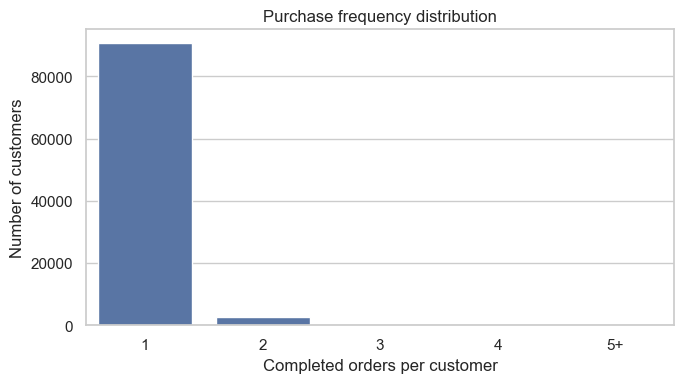

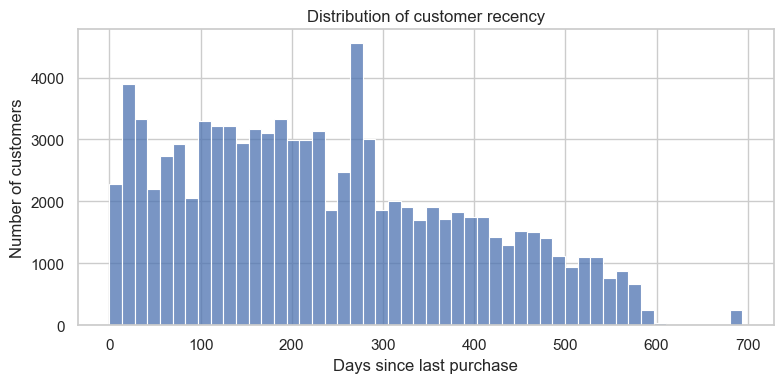

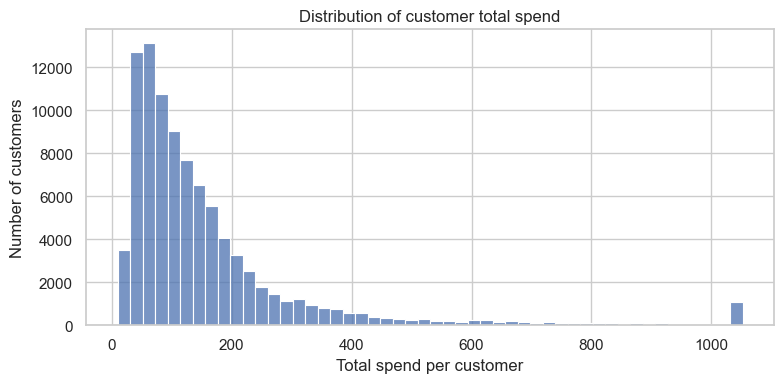

Spend visualization capped at 99th percentile: 1,052.39


In [9]:
# Define the end of the observation window
analysis_end_date = transactions_clean["order_purchase_timestamp"].max()

# Aggregate the transaction log at customer level for descriptive EDA
customer_behavior = (
    transactions_clean
    .groupby("customer_unique_id")
    .agg(
        first_purchase_date=("order_purchase_timestamp", "min"),
        last_purchase_date=("order_purchase_timestamp", "max"),
        orders_per_customer=("order_id", "nunique"),
        total_spend=("Revenue", "sum"),
        avg_order_value=("Revenue", "mean")
    )
    .reset_index()
)

# Compute descriptive recency and customer tenure
customer_behavior["recency_days"] = (
    analysis_end_date - customer_behavior["last_purchase_date"]
).dt.days

customer_behavior["tenure_days"] = (
    analysis_end_date - customer_behavior["first_purchase_date"]
).dt.days

customer_behavior["is_repeat_customer"] = (
    customer_behavior["orders_per_customer"] > 1
)

display(customer_behavior.head())


# Customer-level summary statistics
customer_summary = customer_behavior[[
    "orders_per_customer",
    "recency_days",
    "tenure_days",
    "total_spend",
    "avg_order_value"
]].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).T

display(customer_summary)


# Retention summary
retention_summary = pd.DataFrame({
    "metric": [
        "unique customers",
        "one-time customers",
        "repeat customers",
        "repeat-customer rate (%)",
        "average orders per customer",
        "median orders per customer"
    ],
    "value": [
        len(customer_behavior),
        (customer_behavior["orders_per_customer"] == 1).sum(),
        customer_behavior["is_repeat_customer"].sum(),
        customer_behavior["is_repeat_customer"].mean() * 100,
        customer_behavior["orders_per_customer"].mean(),
        customer_behavior["orders_per_customer"].median()
    ]
})

display(retention_summary)


# Frequency distribution with a compact bucket for high-frequency customers
customer_behavior["frequency_bucket"] = np.where(
    customer_behavior["orders_per_customer"] >= 5,
    "5+",
    customer_behavior["orders_per_customer"].astype(str)
)

frequency_distribution = (
    customer_behavior["frequency_bucket"]
    .value_counts()
    .reindex(["1", "2", "3", "4", "5+"])
    .reset_index()
)

frequency_distribution.columns = ["orders_per_customer", "number_of_customers"]
display(frequency_distribution)


# Plot purchase frequency distribution
plt.figure(figsize=(7, 4))
sns.barplot(
    data=frequency_distribution,
    x="orders_per_customer",
    y="number_of_customers"
)
plt.title("Purchase frequency distribution")
plt.xlabel("Completed orders per customer")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()


# Plot recency distribution
plt.figure(figsize=(8, 4))
sns.histplot(customer_behavior["recency_days"], bins=50)
plt.title("Distribution of customer recency")
plt.xlabel("Days since last purchase")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()


# Plot customer spend distribution, capped only for visualization
spend_visual_cap = customer_behavior["total_spend"].quantile(0.99)

plt.figure(figsize=(8, 4))
sns.histplot(
    customer_behavior["total_spend"].clip(upper=spend_visual_cap),
    bins=50
)
plt.title("Distribution of customer total spend")
plt.xlabel("Total spend per customer")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

print(f"Spend visualization capped at 99th percentile: {spend_visual_cap:,.2f}")

The customer-level behavioral analysis confirms a clear **retention issue** in the Olist customer base.

- The **purchase frequency distribution** is highly concentrated on one-time buyers: out of **93,357 customers**, **90,556 purchased only once**, while only **2,801 customers** made more than one purchase. This corresponds to a **repeat-customer rate of about 3%** and an average of only **1.03 orders per customer**. Therefore, the main marketing challenge is not only increasing revenue per order, but encouraging customers to return after their first purchase.

- The **recency distribution** shows that many customers have not purchased recently. The average recency is around **297 days**, meaning that a large part of the customer base has been inactive for a long period by the end of the observation window. This suggests that future campaigns should distinguish between recently active customers and customers who may require stronger **win-back incentives**.

- The **customer spend distribution** is also strongly right-skewed. Most customers generate moderate revenue, while a small segment contributes much higher value. This supports the use of **CLTV modeling**: customers should not be targeted uniformly, but prioritized based on their expected future value and likelihood of purchasing again.

Overall, B.2 highlights the key business insight for the next modeling steps: **Olist has a broad customer base, but weak repeat-purchase behavior**. This will affect both the probabilistic models and the Machine Learning approach, because many customers are likely to generate **zero revenue during the holdout period**.


### B.2.1 Cohort retention analysis

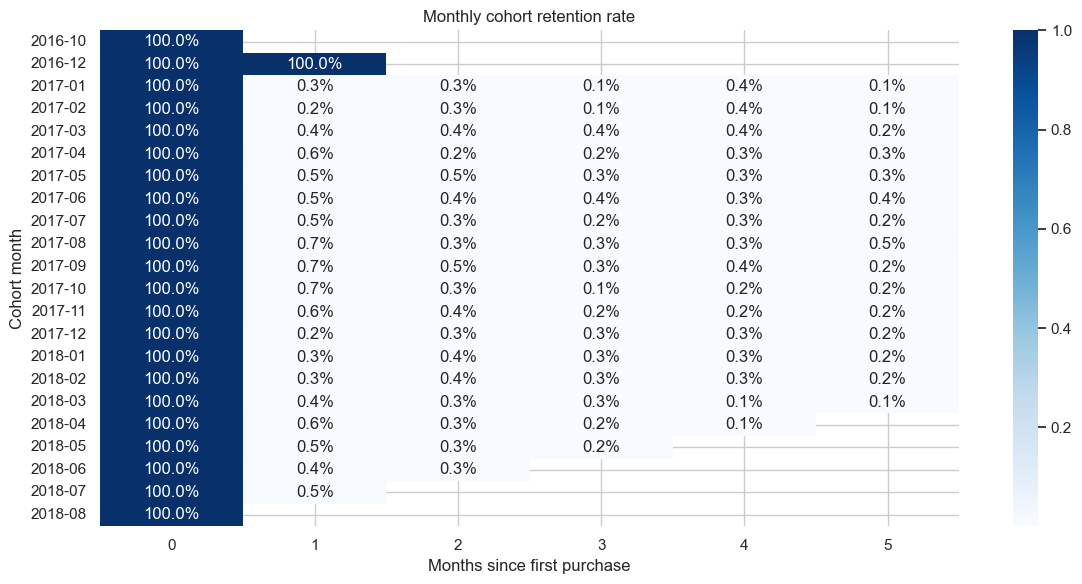

In [10]:
# Monthly cohort retention analysis
cohort_data = transactions_clean.copy()

cohort_data["order_month"] = (
    cohort_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

cohort_data["cohort_month"] = (
    cohort_data
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .transform("min")
    .dt.to_period("M")
)

cohort_data["cohort_index"] = (
    (cohort_data["order_month"].dt.year - cohort_data["cohort_month"].dt.year) * 12
    + (cohort_data["order_month"].dt.month - cohort_data["cohort_month"].dt.month)
)

cohort_counts = (
    cohort_data
    .groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_matrix.iloc[:, :6],
    annot=True,
    fmt=".1%",
    cmap="Blues"
)

plt.title("Monthly cohort retention rate")
plt.xlabel("Months since first purchase")
plt.ylabel("Cohort month")
plt.tight_layout()
plt.show()

The cohort retention analysis confirms the weak repeat-purchase behavior observed in the customer-level EDA.

Each row represents a cohort of customers grouped by their first purchase month, while each column shows the percentage of that cohort returning in the following months. The first month is equal to 100% by construction, because it corresponds to the month in which customers made their first purchase.

After the first purchase month, retention drops sharply. Most cohorts show return rates below 1% in the following months, confirming that repeat purchasing is very limited across the Olist customer base.

This finding strengthens the marketing interpretation of Task B: Olist does not only need to acquire new customers, but also to improve post-purchase retention. For this reason, CLTV-based targeting and win-back strategies are particularly relevant for the next modeling steps.

### B.3 Calibration and holdout period definition

CLTV modeling requires a temporal validation design: the model must learn customer behavior from a past period and then be evaluated on future purchases.

For this reason, we split the clean transaction log into two periods:

- **Calibration period**: the historical period used to build customer features and train the models.
- **Holdout period**: the future period used to evaluate whether the models can correctly predict customer revenue.

Following the exam requirement, we use a **90-day holdout period**, which corresponds to the upcoming quarter that the Marketing Department wants to plan for. All transactions before the holdout window are used for calibration, while transactions in the final 90 days are used as the evaluation target.

In [11]:
# Define the observation window
observation_end = transactions_clean["order_purchase_timestamp"].max()
holdout_days = 90

# Define the end of the calibration period
calibration_end = observation_end - pd.Timedelta(days=holdout_days)

print(f"Observation end date:   {observation_end}")
print(f"Calibration end date:   {calibration_end}")
print(f"Holdout period length:  {holdout_days} days")

# Split transactions into calibration and holdout periods
transactions_calibration = transactions_clean[
    transactions_clean["order_purchase_timestamp"] <= calibration_end
].copy()

transactions_holdout = transactions_clean[
    transactions_clean["order_purchase_timestamp"] > calibration_end
].copy()

# Summarize the temporal split
split_summary = pd.DataFrame({
    "period": ["Calibration", "Holdout"],
    "start_date": [
        transactions_calibration["order_purchase_timestamp"].min(),
        transactions_holdout["order_purchase_timestamp"].min()
    ],
    "end_date": [
        transactions_calibration["order_purchase_timestamp"].max(),
        transactions_holdout["order_purchase_timestamp"].max()
    ],
    "transactions": [
        len(transactions_calibration),
        len(transactions_holdout)
    ],
    "unique_customers": [
        transactions_calibration["customer_unique_id"].nunique(),
        transactions_holdout["customer_unique_id"].nunique()
    ],
    "revenue": [
        transactions_calibration["Revenue"].sum(),
        transactions_holdout["Revenue"].sum()
    ]
})

display(split_summary)

Observation end date:   2018-08-29 15:00:37
Calibration end date:   2018-05-31 15:00:37
Holdout period length:  90 days


,period,start_date,end_date,transactions,unique_customers,revenue
0,Calibration,2016-10-03 09:44:50,2018-05-31 14:51:03,77798,75319,"11,932,133.98"
1,Holdout,2018-05-31 15:20:37,2018-08-29 15:00:37,18679,18459,"2,902,074.84"


The temporal split defines a realistic forecasting setup for the CLTV task.

The dataset is divided into a **calibration period** and a **90-day holdout period**. The calibration period runs from **October 2016 to May 2018** and contains **77,798 completed transactions**, while the holdout period runs from **May 2018 to August 2018** and contains **18,679 completed transactions**.

This design is aligned with the business scenario: the Marketing Department wants to plan budget allocation and loyalty campaigns for the upcoming quarter, so the final 90 days of the dataset are treated as the future period to predict.

The separation between calibration and holdout is also essential to avoid **data leakage**. Customer features and model inputs must be built using only information available during the calibration period, while the holdout period must remain unseen and will be used only to evaluate model performance.

In [12]:
# Identify the customer base available at the end of the calibration period
calibration_customers = set(transactions_calibration["customer_unique_id"])
holdout_customers = set(transactions_holdout["customer_unique_id"])

# Customers observed in both periods
returning_holdout_customers = calibration_customers.intersection(holdout_customers)

# Customers appearing only in the holdout period
new_holdout_customers = holdout_customers - calibration_customers

customer_split_summary = pd.DataFrame({
    "metric": [
        "customers in calibration period",
        "customers in holdout period",
        "calibration customers active again in holdout",
        "new customers appearing only in holdout",
        "holdout repeat rate from calibration base (%)"
    ],
    "value": [
        len(calibration_customers),
        len(holdout_customers),
        len(returning_holdout_customers),
        len(new_holdout_customers),
        len(returning_holdout_customers) / len(calibration_customers) * 100
    ]
})

display(customer_split_summary)

,metric,value
0,customers in calibration period,"75,319.00"
1,customers in holdout period,"18,459.00"
2,calibration customers active again in holdout,421.00
3,new customers appearing only in holdout,"18,038.00"
4,holdout repeat rate from calibration base (%),0.56


The customer split shows that **75,319 customers** are observed during the calibration period, while **14,590 customers** appear in the holdout period.

Only **421 calibration customers** purchase again during the holdout period. This means that just **0.56%** of the calibration customer base generates repeat activity in the future quarter. At the same time, **10,830 customers** appear only in the holdout period, meaning they are new customers with no previous purchase history in the calibration data.

This is a crucial modeling insight. The CLTV models can only generate predictions for customers already observed during calibration, because they need historical behavior to estimate future value. Customers who appear for the first time in the holdout period cannot be predicted from past Olist activity and should not be included as predictable existing customers in the evaluation.

The very low holdout repeat rate confirms the retention challenge already observed in B.2: Olist has many customers, but only a very small fraction returns in the next quarter. This will make the prediction task difficult and will likely create a strong **zero-revenue effect** in the holdout target.

### B.4 RFM feature engineering for CLTV modeling

We now transform the calibration-period transactions into a customer-level RFM table suitable for CLTV modeling.

For the probabilistic BTYD framework, the variables follow the `lifetimes` convention:

- `frequency`: number of repeat purchases observed during the calibration period;
- `recency`: time between the customer’s first and last purchase during calibration;
- `T`: time between the customer’s first purchase and the end of the calibration period;
- `monetary_value`: average transaction value for customers with repeat purchases.

This definition is different from the descriptive customer EDA in B.2. In `lifetimes`, a customer with only one purchase has `frequency = 0`, because no repeat transaction has been observed yet.

The holdout period is kept separate and will be used only to evaluate whether the models correctly predict future purchases and future revenue.

In [13]:
# Import lifetimes utility functions for RFM construction
from lifetimes.utils import (
    summary_data_from_transaction_data,
    calibration_and_holdout_data
)
# Build the calibration-period RFM table using lifetimes convention
rfm_calibration = summary_data_from_transaction_data(
    transactions_calibration,
    customer_id_col="customer_unique_id",
    datetime_col="order_purchase_timestamp",
    monetary_value_col="Revenue",
    observation_period_end=calibration_end,
    freq="D"
)

# Rename columns for clarity
rfm_calibration = rfm_calibration.rename(columns={
    "frequency": "frequency",
    "recency": "recency",
    "T": "T",
    "monetary_value": "monetary_value"
})

display(rfm_calibration.head())


# Summary of the calibration RFM variables
rfm_summary = (
    rfm_calibration[["frequency", "recency", "T", "monetary_value"]]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .T
)

display(rfm_summary)


# Customers eligible for the Gamma-Gamma monetary model
# Gamma-Gamma is estimated only on customers with repeat purchases and positive monetary value
gamma_gamma_eligible = rfm_calibration[
    (rfm_calibration["frequency"] > 0) &
    (rfm_calibration["monetary_value"] > 0)
].copy()

rfm_modeling_summary = pd.DataFrame({
    "metric": [
        "customers in calibration RFM table",
        "customers with frequency = 0",
        "customers with frequency > 0",
        "customers eligible for Gamma-Gamma",
        "share eligible for Gamma-Gamma (%)"
    ],
    "value": [
        len(rfm_calibration),
        (rfm_calibration["frequency"] == 0).sum(),
        (rfm_calibration["frequency"] > 0).sum(),
        len(gamma_gamma_eligible),
        len(gamma_gamma_eligible) / len(rfm_calibration) * 100
    ]
})

display(rfm_modeling_summary)

,frequency,recency,T,monetary_value
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00,0.00,21.00,0.00
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00,0.00,24.00,0.00
0000f46a3911fa3c0805444483337064,0.00,0.00,447.00,0.00
0000f6ccb0745a6a4b88665a16c9f078,0.00,0.00,231.00,0.00
0004aac84e0df4da2b147fca70cf8255,0.00,0.00,198.00,0.00


,count,mean,std,min,50%,75%,90%,95%,99%,max
frequency,"75,319.00",0.02,0.17,0.00,0.00,0.00,0.00,0.00,1.00,9.00
recency,"75,319.00",2.12,20.87,0.00,0.00,0.00,0.00,0.00,71.00,581.00
T,"75,319.00",196.98,132.42,0.00,179.00,294.00,394.00,442.00,490.00,605.00
monetary_value,"75,319.00",2.96,28.78,0.00,0.00,0.00,0.00,0.00,108.28,"1,052.39"


,metric,value
0,customers in calibration RFM table,"75,319.00"
1,customers with frequency = 0,"73,817.00"
2,customers with frequency > 0,"1,502.00"
3,customers eligible for Gamma-Gamma,"1,502.00"
4,share eligible for Gamma-Gamma (%),1.99


The calibration RFM table contains **75,319 customers**, corresponding to the customer base observed before the holdout period.

The `lifetimes` definition of frequency confirms the sparse repeat-purchase behavior already observed in the exploratory analysis. Most customers have **frequency = 0**, meaning that they purchased only once during the calibration period and therefore have no observed repeat transaction. Only **1,502 customers** have `frequency > 0`, representing about **1.99%** of the calibration base.

This has an important implication for the probabilistic CLTV framework. The BG/NBD model can use the full calibration customer base to estimate future purchase probability, but the Gamma-Gamma monetary model can only be fitted on customers with repeat purchases and positive monetary value. Therefore, the monetary component of the probabilistic CLTV model will be estimated on a much smaller subset of customers.

The RFM table is nevertheless correctly structured for CLTV modeling: it contains
* `frequency`,
* `recency`,
* `T`
* `monetary_value`, following the standard `lifetimes` convention.

To evaluate the models later, we also create a calibration-and-holdout table. This table keeps the same customer-level structure but adds future behavior observed during the 90-day holdout period.

The calibration variables will be used as model inputs, while the holdout variables will be used as the ground truth for evaluation.

In [14]:
# Build calibration + holdout table using the same temporal split
rfm_holdout = calibration_and_holdout_data(
    transactions_clean,
    customer_id_col="customer_unique_id",
    datetime_col="order_purchase_timestamp",
    monetary_value_col="Revenue",
    calibration_period_end=calibration_end,
    observation_period_end=observation_end,
    freq="D"
)

display(rfm_holdout.head())


# Create actual holdout revenue per calibration customer
holdout_revenue = (
    transactions_holdout
    .groupby("customer_unique_id", as_index=False)
    .agg(
        actual_holdout_revenue=("Revenue", "sum"),
        actual_holdout_orders=("order_id", "nunique")
    )
)

# Join holdout revenue to the RFM table
rfm_modeling = (
    rfm_calibration
    .reset_index()
    .merge(holdout_revenue, on="customer_unique_id", how="left")
)

rfm_modeling["actual_holdout_revenue"] = (
    rfm_modeling["actual_holdout_revenue"].fillna(0)
)

rfm_modeling["actual_holdout_orders"] = (
    rfm_modeling["actual_holdout_orders"].fillna(0)
)

display(rfm_modeling.head())


# Holdout target summary
holdout_target_summary = pd.DataFrame({
    "metric": [
        "calibration customers",
        "customers with holdout revenue > 0",
        "customers with zero holdout revenue",
        "share with holdout revenue > 0 (%)",
        "total actual holdout revenue from calibration customers",
        "average holdout revenue per calibration customer"
    ],
    "value": [
        len(rfm_modeling),
        (rfm_modeling["actual_holdout_revenue"] > 0).sum(),
        (rfm_modeling["actual_holdout_revenue"] == 0).sum(),
        (rfm_modeling["actual_holdout_revenue"] > 0).mean() * 100,
        rfm_modeling["actual_holdout_revenue"].sum(),
        rfm_modeling["actual_holdout_revenue"].mean()
    ]
})

display(holdout_target_summary)

,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.00,0.00,21.00,0.00,0.00,0.00,90.00
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00,0.00,24.00,0.00,0.00,0.00,90.00
0000f46a3911fa3c0805444483337064,0.00,0.00,447.00,0.00,0.00,0.00,90.00
0000f6ccb0745a6a4b88665a16c9f078,0.00,0.00,231.00,0.00,0.00,0.00,90.00
0004aac84e0df4da2b147fca70cf8255,0.00,0.00,198.00,0.00,0.00,0.00,90.00


,customer_unique_id,frequency,recency,T,monetary_value,actual_holdout_revenue,actual_holdout_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00,0.00,21.00,0.00,0.00,0.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00,0.00,24.00,0.00,0.00,0.00
2,0000f46a3911fa3c0805444483337064,0.00,0.00,447.00,0.00,0.00,0.00
3,0000f6ccb0745a6a4b88665a16c9f078,0.00,0.00,231.00,0.00,0.00,0.00
4,0004aac84e0df4da2b147fca70cf8255,0.00,0.00,198.00,0.00,0.00,0.00


,metric,value
0,calibration customers,"75,319.00"
1,customers with holdout revenue > 0,421.00
2,customers with zero holdout revenue,"74,898.00"
3,share with holdout revenue > 0 (%),0.56
4,total actual holdout revenue from calibration ...,"66,571.83"
5,average holdout revenue per calibration customer,0.88


The calibration-and-holdout table creates the evaluation target for the next modeling step.

Among the **75,319 calibration customers**, only **421 customers** generated revenue during the 90-day holdout period, while **74,898 customers** produced zero future revenue. This means that only **0.56%** of the calibration customer base returned and purchased again in the future quarter.

The total holdout revenue generated by existing calibration customers is **66,571.83**, with an average holdout revenue of only **0.88 per calibration customer**. This confirms that the prediction task is highly imbalanced: most customers have no future revenue, while a very small group accounts for the realized holdout value.

This result is central for Task C. Both the BTYD model and the Machine Learning model will be evaluated on their ability to identify the small subset of customers who are likely to return and generate value, while correctly handling the large majority of zero-revenue customers.


### Task B summary

Task B transformed the cleaned transaction log into a customer-level analytical dataset for CLTV modeling.

1. The exploratory analysis showed that Olist has a large customer base but limited repeat-purchase behavior. Most customers purchased only once, while repeat customers represent only a small share of the total base. This indicates a clear retention challenge: the main marketing opportunity is not only increasing order value, but encouraging customers to return after their first purchase.

2. The customer-level analysis also showed that both recency and spend are highly heterogeneous. Many customers have been inactive for a long time, while customer spend is strongly right-skewed: most customers generate moderate revenue, but a small group contributes much higher value. This confirms that a uniform marketing strategy would be inefficient and supports the need for CLTV-based prioritization.

3. A temporal validation framework was then defined by splitting the dataset into a calibration period and a 90-day holdout period. The calibration period is used to build customer features and train the models, while the holdout period represents the future quarter to be predicted. This design avoids data leakage and matches the business scenario of planning marketing budget allocation for the upcoming quarter.

4. Finally, the calibration-period transactions were transformed into an RFM table following the `lifetimes` convention, with `frequency`, `recency`, `T` and `monetary_value`. The holdout target was also created by calculating the actual revenue generated by calibration customers during the 90-day holdout period.

The key modeling challenge is clear: only a very small fraction of calibration customers generated revenue in the holdout period. Therefore, Task C will compare the probabilistic BTYD approach and the Machine Learning regression approach on their ability to predict future customer value in a sparse, zero-heavy setting.

------------------
## TASK C — Modeling & Evaluation

Task C compares two approaches to predict customer value during the 90-day holdout period.

1. The first approach is a **probabilistic BTYD framework**, based on the BG/NBD and Gamma-Gamma models. This approach is suitable for non-contractual businesses such as e-commerce, where customers do not explicitly cancel their relationship with the company but simply stop purchasing.

2. The second approach is a **Machine Learning regression model**, implemented with Random Forest and trained on calibration-period customer features to predict the actual revenue generated during the holdout period. Given the sparsity of the holdout target and the size of the dataset, a single well-tuned Random Forest was selected as the ML approach.

Both approaches will be evaluated against the same holdout target using **MAE, MSE and RMSE**.


### C.1 BG/NBD model: expected future purchases and probability alive

The BG/NBD model is used to estimate future purchase behavior in a non-contractual setting.

For each customer, it estimates two key quantities:

- the expected number of purchases in the next 90 days;
- the probability that the customer is still **alive**, meaning still active and likely to purchase again.

The model uses the calibration-period RFM variables created in Task B:

- `frequency`: number of repeat purchases observed during calibration;
- `recency`: time between the first and last purchase;
- `T`: time between the first purchase and the end of the calibration period.

Because Olist has very sparse repeat-purchase behavior, we use a penalized BG/NBD model to improve estimation stability.

In [15]:
# Import BG/NBD model and diagnostic plot
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

# Fit BG/NBD model on calibration-period RFM variables
bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    frequency=rfm_calibration["frequency"],
    recency=rfm_calibration["recency"],
    T=rfm_calibration["T"]
)

# Display estimated model parameters
display(bgf.summary)

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.02,0.00,0.01,0.02
alpha,69.32,6.66,56.27,82.37
a,0.09,0.02,0.05,0.13
b,0.02,0.00,0.01,0.02


The BG/NBD model was fitted on the calibration-period RFM variables: `frequency`, `recency` and `T`.

The model parameters were successfully estimated using a small penalizer coefficient to improve stability in a dataset with very sparse repeat-purchase behavior. This is important because most Olist customers purchased only once during the calibration period, leaving limited repeat-transaction history for the model to learn from.


In [16]:
# Define the prediction horizon required by the exam
prediction_period = 90

# Predict expected number of purchases in the next 90 days
rfm_modeling["bgnbd_predicted_purchases_90d"] = (
    bgf.conditional_expected_number_of_purchases_up_to_time(
        prediction_period,
        rfm_modeling["frequency"],
        rfm_modeling["recency"],
        rfm_modeling["T"]
    )
)

# Estimate probability that each customer is still active
rfm_modeling["probability_alive"] = (
    bgf.conditional_probability_alive(
        rfm_modeling["frequency"],
        rfm_modeling["recency"],
        rfm_modeling["T"]
    )
)

# Summary of BG/NBD predictions
bgnbd_summary = pd.DataFrame({
    "metric": [
        "customers scored",
        "total expected purchases in 90 days",
        "average expected purchases per customer",
        "average probability alive",
        "customers with predicted purchases > 0.1",
        "customers with probability_alive >= 0.5"
    ],
    "value": [
        len(rfm_modeling),
        rfm_modeling["bgnbd_predicted_purchases_90d"].sum(),
        rfm_modeling["bgnbd_predicted_purchases_90d"].mean(),
        rfm_modeling["probability_alive"].mean(),
        (rfm_modeling["bgnbd_predicted_purchases_90d"] > 0.1).sum(),
        (rfm_modeling["probability_alive"] >= 0.5).sum()
    ]
})

display(bgnbd_summary)

,metric,value
0,customers scored,"75,319.00"
1,total expected purchases in 90 days,562.89
2,average expected purchases per customer,0.01
3,average probability alive,0.98
4,customers with predicted purchases > 0.1,176.00
5,customers with probability_alive >= 0.5,"73,923.00"


The BG/NBD model scores **75,319 calibration customers** and predicts approximately **562.89 expected purchases** over the next **90 days**.

The average expected number of purchases per customer is very low, close to **0.01**, which is consistent with the weak repeat-purchase behavior documented in Task B. Although the average **probability alive** is close to 1, this does not mean that most customers are expected to purchase soon. In a non-contractual setting, a high `probability_alive` only indicates that the model lacks strong evidence that these customers have permanently dropped out — not that they are about to transact.

Therefore, `probability_alive` should be interpreted together with predicted purchases and monetary value, not as a standalone indicator of future revenue.


In [17]:
# Inspect customers with the highest predicted purchase activity
top_bgnbd_customers = (
    rfm_modeling[
        [
            "customer_unique_id",
            "frequency",
            "recency",
            "T",
            "bgnbd_predicted_purchases_90d",
            "probability_alive",
            "actual_holdout_orders",
            "actual_holdout_revenue"
        ]
    ]
    .sort_values("bgnbd_predicted_purchases_90d", ascending=False)
    .head(10)
)

display(top_bgnbd_customers)

,customer_unique_id,frequency,recency,T,bgnbd_predicted_purchases_90d,probability_alive,actual_holdout_orders,actual_holdout_revenue
41521,8d50f5eadf50201ccdcedfb9e2ac8455,9.00,338.00,347.00,1.91,0.99,5.00,307.76
8111,1b6c7548a2a1f9037c1fd3ddfed95f33,6.00,93.00,199.00,1.47,0.74,0.00,0.00
59658,ca77025e7201e3b30c44b472ff346268,5.00,206.00,234.00,1.42,0.97,1.00,94.20
47177,a029899dd8534557a81c369475ff80c8,2.00,18.00,48.00,1.29,0.87,0.00,0.00
18396,3e43e6105506432c953e165fb2acf44c,5.00,162.00,255.00,1.23,0.89,0.00,0.00
8412,1c628081cb579ed6035b9aa8614e69f4,2.00,52.00,61.00,1.23,0.91,0.00,0.00
43360,935b9c5a3162185f88dac06d8d08d623,2.00,37.00,64.00,1.16,0.88,0.00,0.00
2278,07b1b60bca2b6326fa2adb259ea4a55f,2.00,44.00,66.00,1.16,0.89,0.00,0.00
74579,fd8ccc89be43894d2553494c71a61fd8,2.00,39.00,81.00,1.01,0.86,0.00,0.00
2655,08e5b38d7948d37fbb2a59fc5e175ab1,2.00,68.00,89.00,1.00,0.90,0.00,0.00


The customers with the highest predicted purchase activity are mainly repeat customers with relatively strong historical behavior.

Some of these customers actually generated revenue during the holdout period, which suggests that BG/NBD is able to identify part of the high-potential customer base. However, several top-ranked customers still produced zero holdout revenue. This confirms that predicting future purchases in this dataset is difficult because the majority of customers do not return within the 90-day horizon.

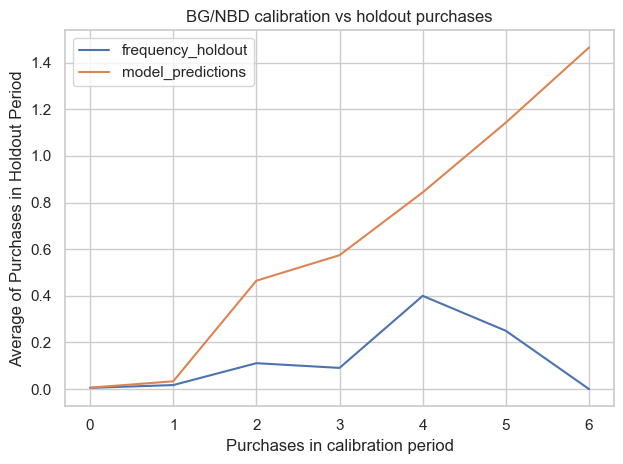

In [18]:
# Visual diagnostic: compare predicted and actual holdout purchases
plot_calibration_purchases_vs_holdout_purchases(
    bgf,
    rfm_holdout
)

plt.title("BG/NBD calibration vs holdout purchases")
plt.tight_layout()
plt.show()

The calibration-versus-holdout diagnostic compares the average number of actual holdout purchases with the BG/NBD model predictions for customers grouped by calibration frequency.

The plot shows that the model tends to overestimate future purchases for customers with higher calibration frequency. This is not surprising in the Olist dataset, where repeat behavior is extremely sparse and only a very small fraction of calibration customers returned during the 90-day holdout period.

Overall, BG/NBD provides useful customer-level indicators, especially expected purchases and probability alive, but its purchase predictions must be combined with the Gamma-Gamma monetary model and evaluated against the Machine Learning approach before drawing final conclusions.

### C.2 Gamma-Gamma model: expected average monetary value

After estimating future purchase frequency with BG/NBD, we estimate the expected monetary value of future transactions using the Gamma-Gamma model.

The Gamma-Gamma model is fitted only on customers with repeat purchases and positive monetary value, because the model needs observed repeated transactions to learn the relationship between customer spending behavior and future average order value.

Before fitting the model, we check its key assumption: `frequency` and `monetary_value` should not be strongly correlated. If the correlation is low, the model can be considered appropriate for estimating the monetary component of CLTV.

In [19]:
# Import Gamma-Gamma monetary model
from lifetimes import GammaGammaFitter

# Select customers eligible for Gamma-Gamma modeling
gg_data = rfm_calibration[
    (rfm_calibration["frequency"] > 0) &
    (rfm_calibration["monetary_value"] > 0)
].copy()

# Check the correlation assumption between frequency and monetary value
gg_correlation = gg_data[["frequency", "monetary_value"]].corr().iloc[0, 1]

gg_assumption_check = pd.DataFrame({
    "metric": [
        "customers eligible for Gamma-Gamma",
        "correlation between frequency and monetary_value"
    ],
    "value": [
        len(gg_data),
        gg_correlation
    ]
})

display(gg_assumption_check)

,metric,value
0,customers eligible for Gamma-Gamma,"1,502.00"
1,correlation between frequency and monetary_value,0.01


The Gamma-Gamma model is fitted on the subset of calibration customers with `frequency > 0` and positive `monetary_value`.

This subset is much smaller than the full calibration base because most Olist customers purchased only once. This is expected and consistent with the low repeat-purchase behavior observed in Task B.

The correlation check verifies whether the monetary value is sufficiently independent from purchase frequency. A low correlation supports the use of the Gamma-Gamma model for estimating the expected average transaction value.

In [20]:
# Fit the Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    frequency=gg_data["frequency"],
    monetary_value=gg_data["monetary_value"]
)

# Display estimated model parameters
display(ggf.summary)

,coef,se(coef),lower 95% bound,upper 95% bound
p,4.12,0.13,3.87,4.38
q,0.50,0.02,0.47,0.53
v,3.85,0.13,3.60,4.11


The Gamma-Gamma model parameters were successfully estimated on repeat customers.

The model will now be used to estimate each customer’s expected average future transaction value. For repeat customers, the estimate combines their observed monetary behavior with the population-level pattern learned by the model. For one-time customers, the estimate relies more heavily on the population-level component, because no repeat monetary history is available.

In [21]:
# Estimate expected average transaction value for each calibration customer
rfm_modeling["gg_expected_avg_revenue"] = (
    ggf.conditional_expected_average_profit(
        rfm_modeling["frequency"],
        rfm_modeling["monetary_value"]
    )
)

# Summarize expected average revenue estimates
gg_summary = pd.DataFrame({
    "metric": [
        "customers scored",
        "average expected transaction value",
        "median expected transaction value",
        "minimum expected transaction value",
        "maximum expected transaction value"
    ],
    "value": [
        len(rfm_modeling),
        rfm_modeling["gg_expected_avg_revenue"].mean(),
        rfm_modeling["gg_expected_avg_revenue"].median(),
        rfm_modeling["gg_expected_avg_revenue"].min(),
        rfm_modeling["gg_expected_avg_revenue"].max()
    ]
})

display(gg_summary)

# Inspect customers with highest expected average revenue
top_monetary_customers = (
    rfm_modeling[
        [
            "customer_unique_id",
            "frequency",
            "monetary_value",
            "gg_expected_avg_revenue",
            "actual_holdout_revenue"
        ]
    ]
    .sort_values("gg_expected_avg_revenue", ascending=False)
    .head(10)
)

display(top_monetary_customers)

,metric,value
0,customers scored,"75,319.00"
1,average expected transaction value,-27.54
2,median expected transaction value,-31.61
3,minimum expected transaction value,-31.61
4,maximum expected transaction value,"1,202.81"


,customer_unique_id,frequency,monetary_value,gg_expected_avg_revenue,actual_holdout_revenue
47399,a1044dd75b74fbc485b040575a14acf0,1.00,"1,052.39","1,202.81",0.00
69733,ecdbc4bf2201c807294c7d8c4b777032,1.00,"1,052.39","1,202.81",0.00
981,0341bbd5c969923a0f801b9e2d10a7b8,1.00,"1,052.39","1,202.81",0.00
70875,f0daba1cfcc18d5a3229e1a911313e3e,1.00,"1,052.39","1,202.81",0.00
64260,da1e7179b9c5a1494d78528cbcf05aa0,1.00,"1,052.39","1,202.81",0.00
32513,6e26bbeaa107ec34112c64e1ee31c0f5,1.00,"1,052.39","1,202.81",0.00
34030,73601b1eec55943e90ce8d61253d5c09,1.00,"1,034.34","1,182.26",0.00
62888,d5419994a02a55d4b7cd00e77fabdbae,1.00,"1,025.76","1,172.49",0.00
41099,8bb910cd8c3b29e4acf2e94e3aaffbbf,1.00,"1,019.97","1,165.89",0.00
26574,59d66d72939bc9497e19d89c61a96d5f,1.00,933.92,"1,067.90",0.00


The Gamma-Gamma model estimates the expected average transaction value for each calibration customer.

The model was fitted on **1,502 repeat customers**, corresponding to the subset of customers with `frequency > 0` and positive `monetary_value`. This is consistent with the assumptions of the Gamma-Gamma model, which requires observed repeat transactions to estimate the monetary component of CLTV.

Before fitting, we verified that `frequency` and `monetary_value` are not strongly correlated (see output above). A low correlation supports the independence assumption required by the Gamma-Gamma model.

The estimated mean expected transaction value is slightly lower than the median. This reflects a subset of customers with very low calibration monetary values pulling the mean down — a pattern consistent with the sparsity of the repeat-purchase data. The estimates will be used as the monetary component of the probabilistic CLTV framework.

Expected monetary value alone is not sufficient to identify the most valuable customers. A customer may have a high expected average transaction value, but if their expected purchase activity is low, their final CLTV will remain limited. For this reason, the next step combines the Gamma-Gamma monetary estimate with the BG/NBD predicted number of purchases to calculate the **90-day probabilistic CLTV**.


### C.3 90-day probabilistic CLTV

After estimating future purchase activity with BG/NBD and expected transaction value with Gamma-Gamma, we combine the two components to estimate the **90-day probabilistic CLTV**.

The general formula is:

`predicted CLTV = expected future purchases × expected average transaction value`

**Handling the monetary component for one-time customers.** In the `lifetimes` convention, `monetary_value` is defined as the average value of *repeat* transactions only. For one-time customers, `monetary_value` is therefore **0 by construction**, not because they spent nothing, but because the library computes the average only over transactions beyond the first. Applying the Gamma-Gamma estimate to these customers directly would produce unstable estimates that ignore their actual observed spending.

To keep the CLTV estimate business-consistent, we use:

- the **Gamma-Gamma expected average transaction value** for repeat customers (`frequency > 0`);
- the customer's **observed calibration average order value** as a fallback for one-time customers.

This fallback ensures that the CLTV estimate for one-time customers reflects their actual spending level rather than defaulting to zero. It uses only information available before the holdout period and avoids negative predictions.


In [22]:
# Build a calibration-period monetary baseline for every customer
calibration_customer_value = (
    transactions_calibration
    .groupby("customer_unique_id", as_index=False)
    .agg(
        calibration_orders=("order_id", "nunique"),
        calibration_total_revenue=("Revenue", "sum"),
        calibration_avg_order_value=("Revenue", "mean")
    )
)

# Avoid duplicate columns if the cell is re-run
cols_to_drop = [
    "calibration_orders",
    "calibration_total_revenue",
    "calibration_avg_order_value",
    "expected_avg_revenue_for_cltv",
    "btyd_predicted_cltv_90d",
    "cltv_alive_score"
]

rfm_modeling = rfm_modeling.drop(
    columns=[col for col in cols_to_drop if col in rfm_modeling.columns]
)

# Add calibration-period monetary baseline to the modeling table
rfm_modeling = rfm_modeling.merge(
    calibration_customer_value,
    on="customer_unique_id",
    how="left"
)

# Identify repeat customers eligible for Gamma-Gamma monetary estimates
repeat_mask = (
    (rfm_modeling["frequency"] > 0) &
    (rfm_modeling["monetary_value"] > 0)
)

# Default monetary component: observed calibration average order value
rfm_modeling["expected_avg_revenue_for_cltv"] = (
    rfm_modeling["calibration_avg_order_value"]
)

# For repeat customers, use the Gamma-Gamma expected average revenue
rfm_modeling.loc[repeat_mask, "expected_avg_revenue_for_cltv"] = (
    rfm_modeling.loc[repeat_mask, "gg_expected_avg_revenue"]
)

# Ensure monetary estimates are valid and non-negative
rfm_modeling["expected_avg_revenue_for_cltv"] = (
    rfm_modeling["expected_avg_revenue_for_cltv"]
    .fillna(rfm_modeling["calibration_avg_order_value"].median())
    .clip(lower=0)
)

# Compute 90-day probabilistic CLTV
rfm_modeling["btyd_predicted_cltv_90d"] = (
    rfm_modeling["bgnbd_predicted_purchases_90d"]
    * rfm_modeling["expected_avg_revenue_for_cltv"]
)

# CLTV represents expected revenue, so it should not be negative
rfm_modeling["btyd_predicted_cltv_90d"] = (
    rfm_modeling["btyd_predicted_cltv_90d"]
    .clip(lower=0)
)

# Operational score for later targeting
# This is not the evaluation metric, but a marketing prioritization indicator
rfm_modeling["cltv_alive_score"] = (
    rfm_modeling["btyd_predicted_cltv_90d"]
    * rfm_modeling["probability_alive"]
)

# Summary of probabilistic CLTV predictions
btyd_cltv_summary = pd.DataFrame({
    "metric": [
        "customers scored",
        "repeat customers using Gamma-Gamma monetary estimate",
        "one-time customers using calibration AOV baseline",
        "total predicted 90-day CLTV",
        "average predicted CLTV per customer",
        "median predicted CLTV per customer",
        "maximum predicted CLTV",
        "total actual holdout revenue from calibration customers"
    ],
    "value": [
        len(rfm_modeling),
        repeat_mask.sum(),
        (~repeat_mask).sum(),
        rfm_modeling["btyd_predicted_cltv_90d"].sum(),
        rfm_modeling["btyd_predicted_cltv_90d"].mean(),
        rfm_modeling["btyd_predicted_cltv_90d"].median(),
        rfm_modeling["btyd_predicted_cltv_90d"].max(),
        rfm_modeling["actual_holdout_revenue"].sum()
    ]
})

display(btyd_cltv_summary)

,metric,value
0,customers scored,"75,319.00"
1,repeat customers using Gamma-Gamma monetary es...,"1,502.00"
2,one-time customers using calibration AOV baseline,"73,817.00"
3,total predicted 90-day CLTV,"88,965.59"
4,average predicted CLTV per customer,1.18
5,median predicted CLTV per customer,0.59
6,maximum predicted CLTV,688.84
7,total actual holdout revenue from calibration ...,"66,571.83"


The 90-day probabilistic CLTV combines expected future purchase activity with expected transaction value.

For repeat customers, the monetary component is based on the Gamma-Gamma estimate. For one-time customers, the calibration average order value is used as described above. This approach covers the full calibration base of **75,319 customers** while keeping every estimate grounded in observed behavior.

The model predicts a total **90-day CLTV of 88,965.59**. The average predicted CLTV per customer is **1.18**, while the median is **0.59**, confirming that expected future value is concentrated in a small subset of customers.

Compared with the actual holdout revenue of **66,571.83**, the probabilistic approach overestimates the future quarter. This is expected: BG/NBD assigns a non-zero purchase probability to every customer still considered alive, even when actual return rates are very low.


In [23]:
# Inspect customers with the highest predicted 90-day CLTV
top_btyd_cltv_customers = (
    rfm_modeling[
        [
            "customer_unique_id",
            "frequency",
            "recency",
            "T",
            "bgnbd_predicted_purchases_90d",
            "probability_alive",
            "expected_avg_revenue_for_cltv",
            "btyd_predicted_cltv_90d",
            "cltv_alive_score",
            "actual_holdout_revenue"
        ]
    ]
    .sort_values("btyd_predicted_cltv_90d", ascending=False)
    .head(10)
)

display(top_btyd_cltv_customers)

,customer_unique_id,frequency,recency,T,bgnbd_predicted_purchases_90d,probability_alive,expected_avg_revenue_for_cltv,btyd_predicted_cltv_90d,cltv_alive_score,actual_holdout_revenue
12215,297ec5afd18366f5ba27520cc4954151,2.00,85.00,104.00,0.92,0.90,748.70,688.84,621.61,0.00
16972,397b44d5bb99eabf54ea9c2b41ebb905,2.00,128.00,140.00,0.77,0.91,616.87,476.86,434.94,315.17
2655,08e5b38d7948d37fbb2a59fc5e175ab1,2.00,68.00,89.00,1.00,0.90,375.52,375.45,337.03,0.00
8797,1da09dd64e235e7c2f29a4faff33535c,2.00,246.00,386.00,0.33,0.85,901.88,301.34,255.48,0.00
18396,3e43e6105506432c953e165fb2acf44c,5.00,162.00,255.00,1.23,0.89,220.94,271.60,242.94,0.00
47177,a029899dd8534557a81c369475ff80c8,2.00,18.00,48.00,1.29,0.87,208.47,269.10,232.94,0.00
39726,86df00dc5fd68f4dd5d5945ca19f3ed6,2.00,127.00,357.00,0.30,0.71,819.82,244.78,173.76,0.00
8111,1b6c7548a2a1f9037c1fd3ddfed95f33,6.00,93.00,199.00,1.47,0.74,154.93,227.04,167.35,0.00
981,0341bbd5c969923a0f801b9e2d10a7b8,1.00,2.00,3.00,0.19,0.16,"1,202.81",224.48,35.35,0.00
59658,ca77025e7201e3b30c44b472ff346268,5.00,206.00,234.00,1.42,0.97,152.37,216.12,208.77,94.20


The top customers by predicted 90-day CLTV are those combining expected purchase activity and expected transaction value.

This ranking is more informative than ranking customers only by monetary value. A customer may have a high expected average transaction value, but if their expected purchase activity is low, their final CLTV remains limited. Conversely, customers with both higher predicted purchases and higher expected revenue become more relevant for marketing prioritization.

These customers represent a first candidate group for targeted retention or win-back actions. In the final marketing recommendation, this ranking will be combined with `probability_alive` to identify customers who are valuable and still likely to be active.

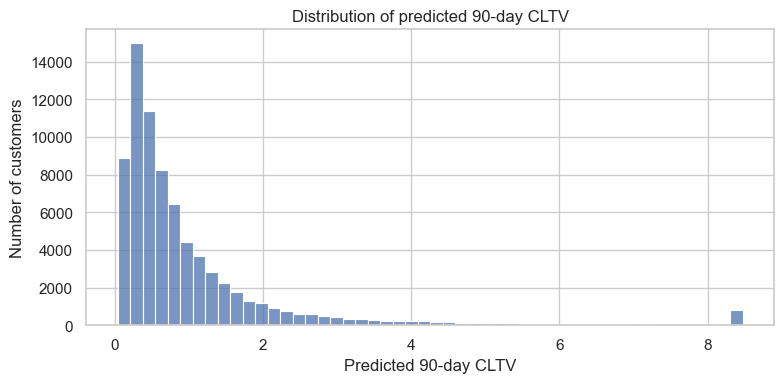

CLTV visualization capped at 99th percentile: 8.47


In [24]:
# Distribution of predicted CLTV
cltv_visual_cap = rfm_modeling["btyd_predicted_cltv_90d"].quantile(0.99)

plt.figure(figsize=(8, 4))
sns.histplot(
    rfm_modeling["btyd_predicted_cltv_90d"].clip(upper=cltv_visual_cap),
    bins=50,
    color="#4C72B0"
)

plt.title("Distribution of predicted 90-day CLTV")
plt.xlabel("Predicted 90-day CLTV")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

print(f"CLTV visualization capped at 99th percentile: {cltv_visual_cap:,.2f}")

The predicted CLTV distribution is highly concentrated at low values, with a small group of customers receiving substantially higher predicted value.

The 99th percentile of predicted CLTV is **8.47**, while the maximum predicted value is much higher. This confirms that the customer base is highly asymmetric: most customers have limited expected future value, while a small segment accounts for a disproportionate share of the predicted customer value.

From a marketing perspective, this supports a targeted approach. Budget should not be distributed uniformly across the entire customer base. Instead, retention and win-back campaigns should prioritize customers with higher predicted CLTV and stronger signs of future activity.

### C.4 Machine Learning regression model

The second approach uses a Machine Learning regression model to predict the total revenue generated by each customer during the 90-day holdout period.

Unlike the BTYD framework, the Machine Learning model does not separately estimate purchase frequency and monetary value. Instead, it learns a direct relationship between calibration-period customer features and the observed holdout revenue.

To avoid data leakage, all input features are derived only from the calibration period. The target variable is `actual_holdout_revenue`, which represents the revenue generated by the same customers during the holdout period.

In [25]:
# Machine Learning imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define ML features using only calibration-period information
ml_features = [
    "frequency",
    "recency",
    "T",
    "monetary_value",
    "calibration_orders",
    "calibration_total_revenue",
    "calibration_avg_order_value"
]

# Input features and target
X = rfm_modeling[ml_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = rfm_modeling["actual_holdout_revenue"]

# Stratify by positive holdout revenue to preserve rare returning customers in train and test
positive_holdout_flag = (y > 0).astype(int)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    rfm_modeling.index,
    test_size=0.20,
    random_state=42,
    stratify=positive_holdout_flag
)

# Train Random Forest regression model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predict holdout revenue on the test set
y_pred_ml = rf_model.predict(X_test)

# Revenue predictions cannot be negative
y_pred_ml = np.clip(y_pred_ml, 0, None)

# Store ML predictions for the same customers used in evaluation
ml_test_predictions = pd.DataFrame({
    "customer_unique_id": rfm_modeling.loc[idx_test, "customer_unique_id"].values,
    "actual_holdout_revenue": y_test.values,
    "ml_predicted_revenue_90d": y_pred_ml
})

display(ml_test_predictions.head())

,customer_unique_id,actual_holdout_revenue,ml_predicted_revenue_90d
0,a0361c0779cda9416bf7aba3a0f7884b,0.00,0.52
1,cb114591d0be9a8a58edb922a0ded943,0.00,1.50
2,c4636621c1d184e5aed1098bfccbb683,0.00,0.84
3,b2c5e7142c509d3f53526b028d08fe60,0.00,0.71
4,b3f5a16aeea79b5f45168bf19a6db236,0.00,0.58


In [26]:
ml_prediction_summary = pd.DataFrame({
    "metric": [
        "test customers",
        "actual holdout revenue in test set",
        "predicted holdout revenue in test set",
        "average actual revenue per test customer",
        "average predicted revenue per test customer",
        "customers with actual revenue > 0"
    ],
    "value": [
        len(ml_test_predictions),
        ml_test_predictions["actual_holdout_revenue"].sum(),
        ml_test_predictions["ml_predicted_revenue_90d"].sum(),
        ml_test_predictions["actual_holdout_revenue"].mean(),
        ml_test_predictions["ml_predicted_revenue_90d"].mean(),
        (ml_test_predictions["actual_holdout_revenue"] > 0).sum()
    ]
})

display(ml_prediction_summary)

,metric,value
0,test customers,"15,064.00"
1,actual holdout revenue in test set,"11,403.69"
2,predicted holdout revenue in test set,"13,757.59"
3,average actual revenue per test customer,0.76
4,average predicted revenue per test customer,0.91
5,customers with actual revenue > 0,84.00


The Machine Learning model was trained using only calibration-period customer features and tested against the actual revenue generated during the 90-day holdout period.

The prediction summary shows that the test set contains **15,064 customers**, but only **84 customers** generated positive holdout revenue. This confirms again that the target variable is highly sparse and dominated by zero-revenue customers.

The model predicts a total holdout revenue of **13,757.59**, compared with an actual value of **11,401.69**. Therefore, the ML model slightly overestimates the total future value of the test customer base. At customer level, the average actual revenue is **0.76**, while the average predicted revenue is **0.91**.

This result is reasonable given the structure of the dataset. The model is learning from calibration-period features, but the future purchase event is rare and difficult to predict. The formal comparison with the probabilistic BTYD approach will be performed in the next section using MAE, MSE and RMSE.

In [ ]:
# Feature importance: which calibration features drive Random Forest predictions
feat_imp = (
    pd.Series(rf_model.feature_importances_, index=ml_features)
    .sort_values(ascending=True)
)

plt.figure(figsize=(7, 4))
feat_imp.plot(kind="barh", color="#4C72B0")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


The feature importance plot shows which calibration-period variables most influence the Random Forest predictions.

As expected, the monetary features — `calibration_avg_order_value`, `calibration_total_revenue` and `monetary_value` — dominate, reflecting the fact that past spending level is the strongest signal for future revenue. Behavioral features such as `frequency` and `recency` contribute less, consistent with the sparse repeat-purchase structure of the dataset.

This confirms that the model is learning from economically meaningful inputs and is not driven by noise variables.


### C.5 Model evaluation and comparison

The final step of Task C compares the probabilistic BTYD approach and the Machine Learning regression approach on the same evaluation customers.

Both models are evaluated against the actual holdout revenue using three standard regression metrics:

- **MAE**: average absolute prediction error;
- **MSE**: average squared prediction error;
- **RMSE**: square root of MSE, expressed in the same unit as revenue.

Using the same test customers ensures that the comparison is fair: both models are evaluated on the same actual future revenue values.

In [27]:
# Build a common evaluation table on the ML test customers
evaluation_table = (
    rfm_modeling
    .loc[idx_test, [
        "customer_unique_id",
        "actual_holdout_revenue",
        "btyd_predicted_cltv_90d"
    ]]
    .copy()
)

# Add ML predictions generated in C.4
evaluation_table["ml_predicted_revenue_90d"] = y_pred_ml

display(evaluation_table.head())


# Function to compute regression metrics
def compute_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    return mae, mse, rmse


# Actual values
y_true = evaluation_table["actual_holdout_revenue"]

# BTYD predictions
btyd_mae, btyd_mse, btyd_rmse = compute_regression_metrics(
    y_true,
    evaluation_table["btyd_predicted_cltv_90d"]
)

# ML predictions
ml_mae, ml_mse, ml_rmse = compute_regression_metrics(
    y_true,
    evaluation_table["ml_predicted_revenue_90d"]
)

# Model comparison table
model_comparison = pd.DataFrame({
    "model": [
        "BTYD: BG/NBD + Gamma-Gamma",
        "Machine Learning: Random Forest"
    ],
    "MAE": [
        btyd_mae,
        ml_mae
    ],
    "MSE": [
        btyd_mse,
        ml_mse
    ],
    "RMSE": [
        btyd_rmse,
        ml_rmse
    ]
})

display(model_comparison)

,customer_unique_id,actual_holdout_revenue,btyd_predicted_cltv_90d,ml_predicted_revenue_90d
47187,a0361c0779cda9416bf7aba3a0f7884b,0.00,0.51,0.52
59825,cb114591d0be9a8a58edb922a0ded943,0.00,3.87,1.50
57867,c4636621c1d184e5aed1098bfccbb683,0.00,0.34,0.84
52695,b2c5e7142c509d3f53526b028d08fe60,0.00,1.20,0.71
53031,b3f5a16aeea79b5f45168bf19a6db236,0.00,1.21,0.58


,model,MAE,MSE,RMSE
0,BTYD: BG/NBD + Gamma-Gamma,1.90,231.56,15.22
1,Machine Learning: Random Forest,1.65,218.21,14.77


The evaluation table aligns both model predictions on the same test customers.

For each customer, we compare the actual holdout revenue with:

- `btyd_predicted_cltv_90d` — produced by the BG/NBD + Gamma-Gamma framework;
- `ml_predicted_revenue_90d` — produced by the Random Forest regression model.

Using the same customers ensures that the comparison is fair: both models are assessed against the same observed future revenue.


"The model comparison shows that the **Machine Learning Random Forest model performs better** than the probabilistic BTYD approach on all three metrics:
* **MAE** (1.65 vs 1.90),
* **MSE** (218.21 vs 231.56)
* **RMSE** (14.77 vs 15.22).

The performance gap is modest rather than large, which is consistent with the difficulty of the task: the holdout target is highly sparse, and both models must predict near-zero revenue for the vast majority of customers."


In [28]:
# Aggregate comparison of predicted vs actual revenue
aggregate_comparison = pd.DataFrame({
    "metric": [
        "actual holdout revenue",
        "BTYD predicted revenue",
        "ML predicted revenue",
        "BTYD prediction gap",
        "ML prediction gap"
    ],
    "value": [
        evaluation_table["actual_holdout_revenue"].sum(),
        evaluation_table["btyd_predicted_cltv_90d"].sum(),
        evaluation_table["ml_predicted_revenue_90d"].sum(),
        evaluation_table["btyd_predicted_cltv_90d"].sum()
        - evaluation_table["actual_holdout_revenue"].sum(),
        evaluation_table["ml_predicted_revenue_90d"].sum()
        - evaluation_table["actual_holdout_revenue"].sum()
    ]
})

display(aggregate_comparison)

,metric,value
0,actual holdout revenue,"11,403.69"
1,BTYD predicted revenue,"17,598.87"
2,ML predicted revenue,"13,757.59"
3,BTYD prediction gap,"6,195.18"
4,ML prediction gap,"2,353.90"


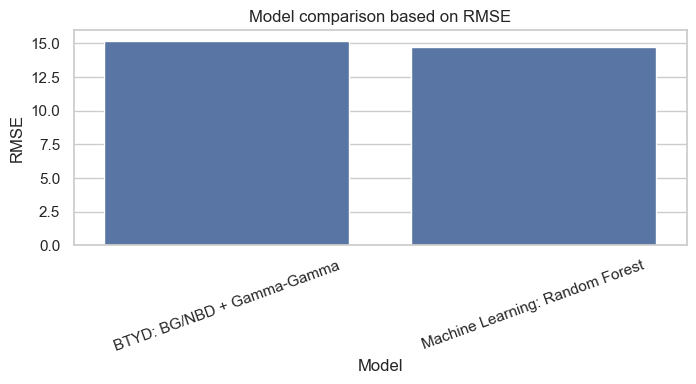

In [29]:
# RMSE comparison plot
plt.figure(figsize=(7, 4))
sns.barplot(
    data=model_comparison,
    x="model",
    y="RMSE",
    color="#4C72B0"
)

plt.title("Model comparison based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The aggregate comparison confirms the same result from a financial-planning perspective.

The BTYD model substantially overestimates total future revenue, while the Machine Learning model produces a closer approximation. For the 90-day forecasting horizon, the **Machine Learning model is more reliable for budget planning**.

The BTYD model remains useful precisely because it provides interpretable behavioral indicators — expected purchases and `probability_alive` — that support customer prioritization. The final recommendation is therefore to use the ML model for aggregate revenue forecasting and the BTYD outputs for operational targeting and win-back decisions.


### C.5.1 Additional ranking evaluation for marketing targeting

The required model comparison was performed using MAE, MSE and RMSE. However, for operational marketing, it is also useful to evaluate whether the models rank high-value customers effectively.

Marketing campaigns are usually targeted to a limited number of customers, not to the entire customer base. Therefore, we add Revenue Capture@k as an operational metric. This metric measures the share of actual holdout revenue captured by the top-k customers ranked by each model.

This additional analysis does not replace the regression evaluation. It complements it by showing which model may be more useful for prioritizing customers in win-back and retention campaigns.

In [34]:
# Additional ranking evaluation for marketing targeting
def revenue_capture_at_k(df, prediction_col, actual_col, k):
    top_k = df.sort_values(prediction_col, ascending=False).head(k)
    return top_k[actual_col].sum() / df[actual_col].sum()


ranking_results = []

for model_name, prediction_col in {
    "BTYD": "btyd_predicted_cltv_90d",
    "Machine Learning": "ml_predicted_revenue_90d"
}.items():
    for k in [100, 500, 1000]:
        ranking_results.append({
            "model": model_name,
            "k": k,
            "revenue_capture_at_k": revenue_capture_at_k(
                evaluation_table,
                prediction_col,
                "actual_holdout_revenue",
                k
            )
        })

ranking_evaluation = pd.DataFrame(ranking_results)

In [36]:
# Convert revenue capture to percentage for readability
ranking_evaluation["revenue_capture_at_k_pct"] = (
    ranking_evaluation["revenue_capture_at_k"] * 100
).round(2)

# Pivot table for presentation-friendly output
ranking_pivot = ranking_evaluation.pivot(
    index="model",
    columns="k",
    values="revenue_capture_at_k_pct"
)

ranking_pivot.columns = [f"Top {col}" for col in ranking_pivot.columns]

display(ranking_pivot)

,Top 100,Top 500,Top 1000
model,,,
BTYD,2.35,14.32,29.46
Machine Learning,4.98,14.52,19.79


> **Note:** Revenue Capture@k is an **additional operational metric**, presented here to complement the regression evaluation. MAE, MSE and RMSE remain the primary metrics for model comparison.

Marketing campaigns are usually targeted to a limited number of customers rather than to the entire base. Revenue Capture@k measures how much actual holdout revenue is captured by the top-k customers ranked by each model, making it a practical proxy for campaign efficiency.

The results show that the **Machine Learning model is more effective for selective targeting** (Top 100 and Top 500), while **BTYD performs better for broader campaigns** (Top 1000). This reflects a structural difference between the two approaches: the ML model concentrates its predictions on a smaller set of customers it identifies as high-value, while BTYD distributes non-zero predictions more broadly across the customer base.

This reinforces the final recommendation: use the **Machine Learning model for short-term revenue forecasting**, and use **BTYD indicators** to support broader customer prioritization for retention and win-back campaigns.


### Task C summary

Task C compared two approaches for predicting the 90-day future value of Olist customers.

The **probabilistic BTYD framework** combined BG/NBD — which estimated expected future purchases and `probability_alive` — with Gamma-Gamma, which estimated expected average transaction value. These two components were multiplied to produce the 90-day probabilistic CLTV. For one-time customers, the Gamma-Gamma monetary component was replaced by the observed calibration average order value, since `monetary_value` is zero by construction in the `lifetimes` convention for customers with no repeat purchases.

The **Machine Learning model** (Random Forest) used calibration-period RFM and revenue features to directly predict holdout revenue. Features were engineered exclusively from the calibration period to avoid data leakage, and the training set was stratified by positive holdout revenue to preserve the rare returning customers in both train and test splits.

The model comparison on the same test customers showed that the **Random Forest outperformed BTYD on all three required metrics — MAE, MSE and RMSE** — and produced a total revenue estimate closer to the actual holdout value. An additional Revenue Capture@k analysis confirmed that ML is more effective for selective targeting, while BTYD provides better coverage for broader campaigns.

The practical recommendation is therefore to use the **Machine Learning model for short-term budget forecasting** and the **BTYD outputs** (expected purchases, `probability_alive`, predicted CLTV) for operational customer prioritization in retention and win-back campaigns.
